## Merges all the availble information into a **Final Dataset** to be used for modeling ##

In [1]:
import pandas as pd
import datetime
import missingno

from sklearn.impute import KNNImputer
import sys
import rpy2.robjects as robjects
import rpy2.ipython.html
from rpy2.robjects.packages import importr
import pickle

rpy2.ipython.html.init_printing()

sys.path.insert(0, "../../../../Modules")
sys.path.insert(0, "../../../../Mamoth")

from utils import *
from Neural_Network_Module import give_predictions, Dataset


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 100
pd.options.display.float_format = lambda x: '%.6f' % x

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\rpy2\robjects\packages.py:367: UserWarning: The symbol 'quartz' is not in this R namespace/package.
  warnings.warn(


In [2]:
utils = importr('utils')
base = importr('base')
dismo = importr('dismo')
utils.chooseCRANmirror(ind=41)

<rpy2.rinterface_lib.sexp.NULLType object at 0x000001CA9A5EC380> [RTYPES.NILSXP]

In [3]:
NUTS0 = 'GR'
NUTS2 = 'Attica'
#NUTS2_EL = 'κεντρικης μακεδονιας'

In [4]:
timeline_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_NUTS3_2010-2022_filled_meantemps.csv', encoding=enc)
wnv_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Cases_NUTS3_2010-2022.csv', encoding=enc)

In [5]:
timeline_file.head()

,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,dt_placement,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall
0,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.760930,37.952630,2010-01-01,1,1,2010,0.121077,0.086852,-0.033350,-0.086852,0.123717,0.087819,-0.034276,-0.087819,0.057889,0.038353,0.013501,0.038353,14624.000000,14325.000000,14624.000000,NaN,NaN,NaN,14325.000000,NaN,NaN,NaN,0.000000
1,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.760930,37.952630,2010-01-02,2,1,2010,0.121077,0.086852,-0.033350,-0.086852,0.123717,0.087819,-0.034276,-0.087819,0.057889,0.038353,0.013501,0.038353,14049.000000,14193.000000,14336.500000,NaN,NaN,NaN,14259.000000,NaN,NaN,NaN,0.000000
2,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.760930,37.952630,2010-01-03,3,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14049.000000,14074.000000,14240.666667,NaN,NaN,NaN,14197.333333,NaN,NaN,NaN,0.000000
3,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.760930,37.952630,2010-01-04,4,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14049.000000,14074.000000,14192.750000,NaN,NaN,NaN,14166.500000,NaN,NaN,NaN,0.000000
4,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.760930,37.952630,2010-01-05,5,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14049.000000,14074.000000,14164.000000,NaN,NaN,NaN,14148.000000,NaN,NaN,NaN,0.000000


In [6]:
wnv_file.head()

,NUTS2_NAME,NUTS3_NAME,dt_placement,cases
0,αττικη,ανατολικη αττικη,2011-05,0
1,αττικη,ανατολικη αττικη,2011-06,0
2,αττικη,ανατολικη αττικη,2011-07,7
3,αττικη,ανατολικη αττικη,2011-08,8
4,αττικη,ανατολικη αττικη,2011-09,5


In [7]:
timeline_file[['NUTS3_NAME', 'dt_placement']].value_counts().sort_values(ascending=False)

NUTS3_NAME             dt_placement
ανατολικη αττικη       2010-01-01      290
                       2010-01-18      290
                       2010-01-04      290
                       2010-01-05      290
                       2010-01-06      290
                                      ... 
δυτικος τομεας αθηνων  2010-01-04        9
                       2010-01-03        9
                       2010-01-09        9
                       2010-01-18        9
                       2016-07-02        9
Length: 33236, dtype: int64

In [8]:
wnv_file[['NUTS3_NAME', 'dt_placement']].value_counts().sort_values(ascending=False)

NUTS3_NAME        dt_placement
ανατολικη αττικη  2011-05         1
                  2012-09         1
                  2011-07         1
                  2011-08         1
                  2011-09         1
                                 ..
πειραιας, νησοι   2021-07         1
                  2021-08         1
                  2021-09         1
                  2018-10         1
                  2021-10         1
Length: 336, dtype: int64

In [9]:
timeline_file['lst'] = (timeline_file['lst_day'] + timeline_file['lst_night']) / 2
timeline_file['lst_jan_mean'] = (timeline_file['lst_day_jan_mean'] + timeline_file['lst_night_jan_mean'])/2
timeline_file['lst_feb_mean'] = (timeline_file['lst_day_feb_mean'] + timeline_file['lst_night_feb_mean'])/2
timeline_file['lst_mar_mean'] = (timeline_file['lst_day_mar_mean'] + timeline_file['lst_night_mar_mean'])/2
timeline_file['lst_apr_mean'] = (timeline_file['lst_day_apr_mean'] + timeline_file['lst_night_apr_mean'])/2

In [10]:
timeline_file.head()

,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,dt_placement,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean
0,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.760930,37.952630,2010-01-01,1,1,2010,0.121077,0.086852,-0.033350,-0.086852,0.123717,0.087819,-0.034276,-0.087819,0.057889,0.038353,0.013501,0.038353,14624.000000,14325.000000,14624.000000,NaN,NaN,NaN,14325.000000,NaN,NaN,NaN,0.000000,14474.500000,14474.500000,NaN,NaN,NaN
1,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.760930,37.952630,2010-01-02,2,1,2010,0.121077,0.086852,-0.033350,-0.086852,0.123717,0.087819,-0.034276,-0.087819,0.057889,0.038353,0.013501,0.038353,14049.000000,14193.000000,14336.500000,NaN,NaN,NaN,14259.000000,NaN,NaN,NaN,0.000000,14121.000000,14297.750000,NaN,NaN,NaN
2,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.760930,37.952630,2010-01-03,3,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14049.000000,14074.000000,14240.666667,NaN,NaN,NaN,14197.333333,NaN,NaN,NaN,0.000000,14061.500000,14219.000000,NaN,NaN,NaN
3,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.760930,37.952630,2010-01-04,4,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14049.000000,14074.000000,14192.750000,NaN,NaN,NaN,14166.500000,NaN,NaN,NaN,0.000000,14061.500000,14179.625000,NaN,NaN,NaN
4,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.760930,37.952630,2010-01-05,5,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14049.000000,14074.000000,14164.000000,NaN,NaN,NaN,14148.000000,NaN,NaN,NaN,0.000000,14061.500000,14156.000000,NaN,NaN,NaN


In [11]:
wnv_file.head(5)

,NUTS2_NAME,NUTS3_NAME,dt_placement,cases
0,αττικη,ανατολικη αττικη,2011-05,0
1,αττικη,ανατολικη αττικη,2011-06,0
2,αττικη,ανατολικη αττικη,2011-07,7
3,αττικη,ανατολικη αττικη,2011-08,8
4,αττικη,ανατολικη αττικη,2011-09,5


### Calculate accumulated rainfall ###

In [12]:
timeline_file.shape

(3029224, 38)

In [13]:
dataset = pd.DataFrame()
groups = timeline_file.groupby(['x', 'y', 'year'])

for group, data in groups:
    temp_df = data.copy()
    temp_df.reset_index(drop=True, inplace=True)
    temp_df['acc_rainfall_1week'] = temp_df['rainfall'].rolling(window=7, min_periods=0).sum()
    temp_df['acc_rainfall_2week'] = temp_df['rainfall'].rolling(window=14, min_periods=0).sum()
    temp_df['acc_rainfall_jan'] = temp_df['dt_placement'].apply(lambda x: temp_df.loc[temp_df['dt_placement'] <= x, 'rainfall'].sum())
    dataset = dataset.append(temp_df)

dataset.reset_index(drop=True, inplace=True)

dataset

,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,dt_placement,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan
0,EL30,αττικη,EL307,"πειραιας, νησοι",22.924050,36.226730,2010-01-01,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14540.000000,14327.000000,14540.000000,NaN,NaN,NaN,14327.000000,NaN,NaN,NaN,0.000000,14433.500000,14433.500000,NaN,NaN,NaN,0.000000,0.000000,0.000000
1,EL30,αττικη,EL307,"πειραιας, νησοι",22.924050,36.226730,2010-01-02,2,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14389.000000,14327.000000,14464.500000,NaN,NaN,NaN,14327.000000,NaN,NaN,NaN,0.000000,14358.000000,14395.750000,NaN,NaN,NaN,0.000000,0.000000,0.000000
2,EL30,αττικη,EL307,"πειραιας, νησοι",22.924050,36.226730,2010-01-03,3,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14357.000000,14327.000000,14428.666667,NaN,NaN,NaN,14327.000000,NaN,NaN,NaN,0.000000,14342.000000,14377.833333,NaN,NaN,NaN,0.000000,0.000000,0.000000
3,EL30,αττικη,EL307,"πειραιας, νησοι",22.924050,36.226730,2010-01-04,4,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14164.000000,14327.000000,14362.500000,NaN,NaN,NaN,14327.000000,NaN,NaN,NaN,0.000000,14245.500000,14344.750000,NaN,NaN,NaN,0.000000,0.000000,0.000000
4,EL30,αττικη,EL307,"πειραιας, νησοι",22.924050,36.226730,2010-01-05,5,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14348.000000,14180.000000,14359.600000,NaN,NaN,NaN,14297.600000,NaN,NaN,NaN,0.000000,14264.000000,14328.600000,NaN,NaN,NaN,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3029219,EL30,αττικη,EL305,ανατολικη αττικη,24.050870,37.792680,2022-12-27,27,12,2022,0.388066,0.127148,-0.299010,-0.127148,0.308107,0.023271,-0.273349,-0.023271,0.038706,0.046829,0.019978,0.046829,14494.000000,14207.000000,14222.161290,14346.571429,14389.741935,14389.741935,13913.774194,13922.607143,13906.322581,13906.322581,0.000000,14350.500000,14067.967742,14134.589286,14148.032258,14148.032258,0.012201,1.284521,767.502467
3029220,EL30,αττικη,EL305,ανατολικη αττικη,24.050870,37.792680,2022-12-28,28,12,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14494.000000,14147.000000,14222.161290,14346.571429,14389.741935,14389.741935,13913.774194,13922.607143,13906.322581,13906.322581,0.000000,14320.500000,14067.967742,14134.589286,14148.032258,14148.032258,0.012201,1.265016,767.502467
3029221,EL30,αττικη,EL305,ανατολικη αττικη,24.050870,37.792680,2022-12-29,29,12,2022,0.388066,0.127148,-0.299010,-0.127148,0.308107,0.023271,-0.273349,-0.023271,0.038706,0.046829,0.019978,0.046829,14494.000000,14149.000000,14222.161290,14346.571429,14389.741935,14389.741935,13913.774194,13922.607143,13906.322581,13906.322581,0.000000,14321.500000,14067.967742,14134.589286,14148.032258,14148.032258,0.012201,0.012201,767.502467
3029222,EL30,αττικη,EL305,ανατολικη αττικη,24.050870,37.792680,2022-12-30,30,12,2022,0.388066,0.127148,-0.299010,-0.127148,0.308107,0.023271,-0.273349,-0.023271,0.038706,0.046829,0.019978,0.046829,14494.000000,14125.000000,14222.161290,14346.571429,14389.741935,14389.741935,13913.774194,13922.607143,13906.322581,13906.322581,0.000000,14309.500000,14067.967742,14134.589286,14148.032258,14148.032258,0.000000,0.012201,767.502467


### Add mosqutio predictions using trained model ###

In [14]:
model = pickle.load(open(f'../../../../Greece/data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Mamoth_NN.pt', 'rb'))
imputer = pickle.load(open(f'../../../../Greece/data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_KNN_Imputer.pkl', 'rb'))
scaler = pickle.load(open(f'../../../../Greece/data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Scaler.pkl', 'rb'))

In [15]:
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'])
dataset['day'] = dataset['dt_placement'].apply(lambda x : x.day)
dataset['month'] = dataset['dt_placement'].apply(lambda x : x.month)
dataset['year'] = dataset['dt_placement'].apply(lambda x : x.year)
dataset['week'] = dataset.apply(lambda row: datetime.date(int(row['year']), int(row['month']), int(row['day'])).isocalendar().week, axis=1)

dataset = encode_cyclical(dataset, 'day', 31)
dataset = encode_cyclical(dataset, 'month', 12)
dataset = encode_cyclical(dataset, 'week', 53)

In [16]:
dataset.rename(columns={"lst_day_jan_mean": "lst_jan_day_mean",
                        "lst_day_feb_mean": "lst_feb_day_mean",
                        "lst_day_mar_mean": "lst_mar_day_mean",
                        "lst_day_apr_mean": "lst_apr_day_mean",
                        "lst_night_jan_mean": "lst_jan_night_mean",
                        "lst_night_feb_mean": "lst_feb_night_mean",
                        "lst_night_mar_mean": "lst_mar_night_mean",
                        "lst_night_apr_mean": "lst_apr_night_mean"}, inplace=True)

In [17]:
mamoth_columns = ['x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
                'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
                'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
                'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
                'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
                'acc_rainfall_jan', 'mosq_now']

features_for_impute = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                        'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean', 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 
                        'lst_day', 'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan']

In [18]:
dataset_mamoth = dataset_mamoth_preparation(dataset, mamoth_columns)

In [19]:
mosqutio_predictions = dataset_mamoth[['x', 'y', 'dt_placement']].copy()
dataset_mamoth.drop(columns=['dt_placement'], inplace=True)
dataset_mamoth_sub = dataset_mamoth[features_for_impute]

In [20]:
mamoth_imputed = pd.DataFrame(imputer.transform(dataset_mamoth_sub), columns = dataset_mamoth_sub.columns)
dataset_mamoth[features_for_impute] = mamoth_imputed[features_for_impute]

<AxesSubplot:>

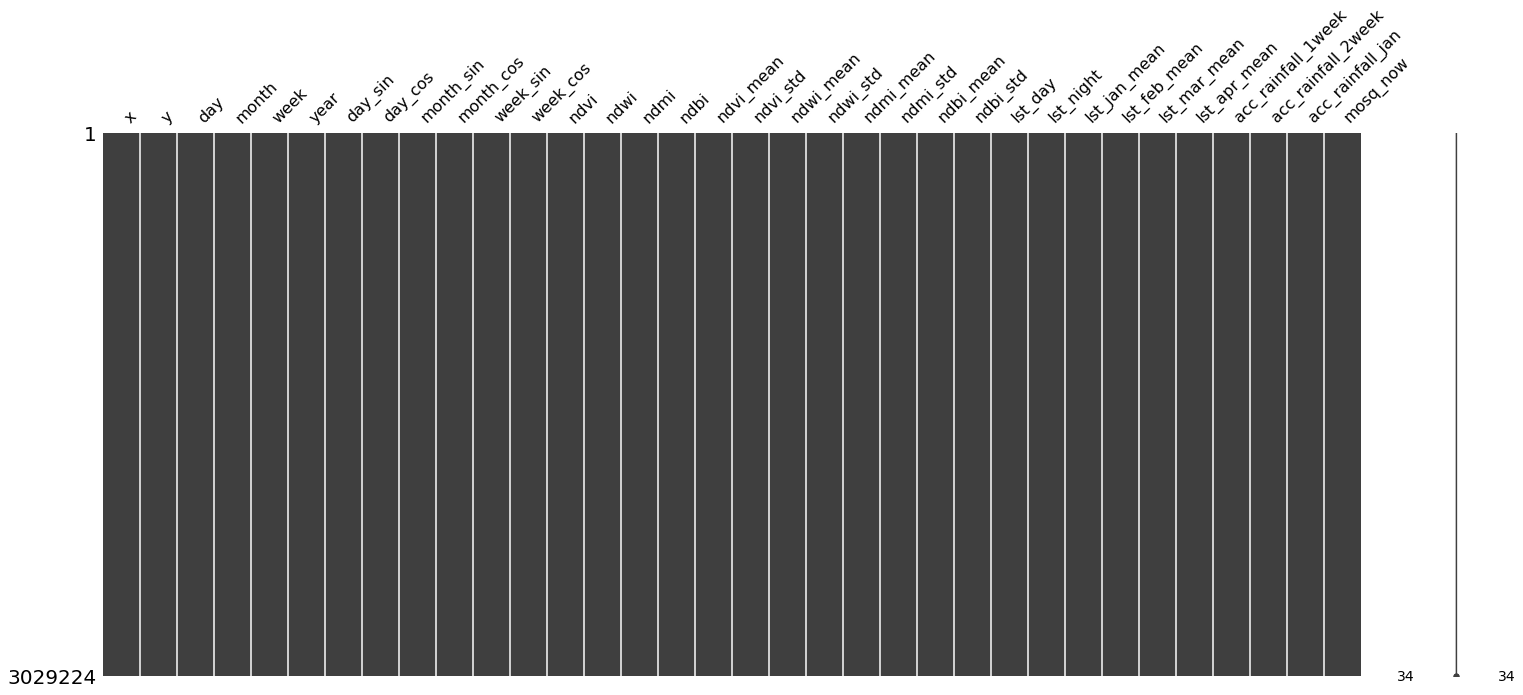

In [21]:
missingno.matrix(dataset_mamoth)

In [22]:
dataset_mamoth_X, dataset_mamoth_y = dataset_mamoth.iloc[:,:-1], dataset_mamoth.iloc[:,-1]

dataset_mamoth_X = scaler.transform(dataset_mamoth_X)

In [23]:
model_type = 'mosquito_regression'
transform_target = True

dataset_mamoth = Dataset(dataset_mamoth_X, dataset_mamoth_y, model_type=model_type, transform = transform_target)

In [24]:
predictions = give_predictions(model, dataset_mamoth)

In [25]:
mosqutio_predictions['mosq_pred'] = predictions
mosqutio_predictions

,x,y,dt_placement,mosq_pred
0,22.924050,36.226730,2010-01-01,399
1,22.924050,36.226730,2010-01-02,387
2,22.924050,36.226730,2010-01-03,388
3,22.924050,36.226730,2010-01-04,243
4,22.924050,36.226730,2010-01-05,272
...,...,...,...,...
3029219,24.050870,37.792680,2022-12-27,7
3029220,24.050870,37.792680,2022-12-28,1
3029221,24.050870,37.792680,2022-12-29,6
3029222,24.050870,37.792680,2022-12-30,6


<AxesSubplot:>

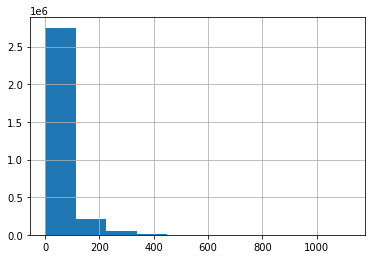

In [26]:
mosqutio_predictions.mosq_pred.hist()

In [27]:
dataset = pd.merge(dataset, mosqutio_predictions,  how='left', on=['x', 'y', 'dt_placement'])

In [28]:
dataset

,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,dt_placement,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred
0,EL30,αττικη,EL307,"πειραιας, νησοι",22.924050,36.226730,2010-01-01,1,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14540.000000,14327.000000,14540.000000,NaN,NaN,NaN,14327.000000,NaN,NaN,NaN,0.000000,14433.500000,14433.500000,NaN,NaN,NaN,0.000000,0.000000,0.000000,53,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,399
1,EL30,αττικη,EL307,"πειραιας, νησοι",22.924050,36.226730,2010-01-02,2,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14389.000000,14327.000000,14464.500000,NaN,NaN,NaN,14327.000000,NaN,NaN,NaN,0.000000,14358.000000,14395.750000,NaN,NaN,NaN,0.000000,0.000000,0.000000,53,0.394356,0.918958,0.500000,0.866025,-0.000000,1.000000,387
2,EL30,αττικη,EL307,"πειραιας, νησοι",22.924050,36.226730,2010-01-03,3,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14357.000000,14327.000000,14428.666667,NaN,NaN,NaN,14327.000000,NaN,NaN,NaN,0.000000,14342.000000,14377.833333,NaN,NaN,NaN,0.000000,0.000000,0.000000,53,0.571268,0.820763,0.500000,0.866025,-0.000000,1.000000,388
3,EL30,αττικη,EL307,"πειραιας, νησοι",22.924050,36.226730,2010-01-04,4,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14164.000000,14327.000000,14362.500000,NaN,NaN,NaN,14327.000000,NaN,NaN,NaN,0.000000,14245.500000,14344.750000,NaN,NaN,NaN,0.000000,0.000000,0.000000,1,0.724793,0.688967,0.500000,0.866025,0.118273,0.992981,243
4,EL30,αττικη,EL307,"πειραιας, νησοι",22.924050,36.226730,2010-01-05,5,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14348.000000,14180.000000,14359.600000,NaN,NaN,NaN,14297.600000,NaN,NaN,NaN,0.000000,14264.000000,14328.600000,NaN,NaN,NaN,0.000000,0.000000,0.000000,1,0.848644,0.528964,0.500000,0.866025,0.118273,0.992981,272
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3029219,EL30,αττικη,EL305,ανατολικη αττικη,24.050870,37.792680,2022-12-27,27,12,2022,0.388066,0.127148,-0.299010,-0.127148,0.308107,0.023271,-0.273349,-0.023271,0.038706,0.046829,0.019978,0.046829,14494.000000,14207.000000,14222.161290,14346.571429,14389.741935,14389.741935,13913.774194,13922.607143,13906.322581,13906.322581,0.000000,14350.500000,14067.967742,14134.589286,14148.032258,14148.032258,0.012201,1.284521,767.502467,52,-0.724793,0.688967,-0.000000,1.000000,-0.118273,0.992981,7
3029220,EL30,αττικη,EL305,ανατολικη αττικη,24.050870,37.792680,2022-12-28,28,12,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14494.000000,14147.000000,14222.161290,14346.571429,14389.741935,14389.741935,13913.774194,13922.607143,13906.322581,13906.322581,0.000000,14320.500000,14067.967742,14134.589286,14148.032258,14148.032258,0.012201,1.265016,767.502467,52,-0.571268,0.820763,-0.000000,1.000000,-0.118273,0.992981,1
3029221,EL30,αττικη,EL305,ανατολικη αττικη,24.050870,37.792680,2022-12-29,29,12,2022,0.388066,0.127148,-0.299010,-0.127148,0.308107,0.023271,-0.273349,-0.023271,0.038706,0.046829,0.019978,0.046829,14494.000000,14149.000000,14222.161290,14346.571429,14389.741935,14389.741935,13913.774194,13922.607143,13906.322581,13906.322581,0.000000,14321.500000,14067.967742,14134.589286,14148.032258,14148.032258,0.012201,0.012201,767.502467,52,-0.394356,0.918958,-0.000000,1.000000,-0.118273,0.992981,6
3029222,EL30,αττικη,EL305,ανατολικη αττικη,24.050870,37.792680,2022-12-30,30,12,2022,0.388066,0.127148,-0.299010,-0.127148,0.308107,0.023271,-0.273349,-0.023271,0.038706,0.046829,0.0

In [29]:
grouped = dataset.groupby(['dt_placement', 'NUTS2_ID',	'NUTS2_NAME',	'NUTS3_ID',	'NUTS3_NAME'], as_index = False)
dataset_grouped = grouped.mean()
dataset_grouped

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred
0,2010-01-01,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.812763,38.047451,1.000000,1.000000,2010.000000,0.238709,0.125007,-0.093093,-0.125007,0.237988,0.124278,-0.095426,-0.124278,0.038738,0.029813,0.027037,0.029813,14546.611111,14247.111111,14546.611111,NaN,NaN,NaN,14247.111111,NaN,NaN,NaN,0.000000,14396.861111,14396.861111,NaN,NaN,NaN,0.000000,0.000000,0.000000,53.000000,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,147.388889
1,2010-01-01,EL30,αττικη,EL302,δυτικος τομεας αθηνων,23.685082,38.018504,1.000000,1.000000,2010.000000,0.148037,0.048113,-0.115208,-0.048113,0.132420,0.041732,-0.098505,-0.041732,0.012587,0.012635,0.018510,0.012635,14608.222222,14287.000000,14608.222222,NaN,NaN,NaN,14287.000000,NaN,NaN,NaN,0.000000,14447.611111,14447.611111,NaN,NaN,NaN,0.000000,0.000000,0.000000,53.000000,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,187.444444
2,2010-01-01,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.754944,37.979104,1.000000,1.000000,2010.000000,0.199024,0.129720,-0.038309,-0.129720,0.183807,0.120342,-0.036695,-0.120342,0.056233,0.037885,0.038611,0.037885,14587.789474,14295.055556,14587.789474,NaN,NaN,NaN,14295.055556,NaN,NaN,NaN,0.000000,14440.194444,14440.194444,NaN,NaN,NaN,0.000000,0.000000,0.000000,53.000000,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,152.263158
3,2010-01-01,EL30,αττικη,EL304,νοτιος τομεας αθηνων,23.749555,37.914897,1.000000,1.000000,2010.000000,0.221100,0.092933,-0.119241,-0.092933,0.205771,0.089282,-0.109884,-0.089282,0.036622,0.016738,0.032846,0.016738,14618.700000,14318.600000,14618.700000,NaN,NaN,NaN,14318.600000,NaN,NaN,NaN,0.000000,14468.650000,14468.650000,NaN,NaN,NaN,0.000000,0.000000,0.000000,53.000000,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,169.400000
4,2010-01-01,EL30,αττικη,EL305,ανατολικη αττικη,23.889386,38.042726,1.000000,1.000000,2010.000000,0.397771,0.155384,-0.199277,-0.155384,0.399240,0.160357,-0.193923,-0.160357,0.037753,0.035591,0.039219,0.035591,14586.219512,14249.841379,14586.219512,NaN,NaN,NaN,14249.841379,NaN,NaN,NaN,0.000000,14418.839721,14418.839721,NaN,NaN,NaN,0.000000,0.000000,0.000000,53.000000,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,145.734483
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33231,2022-12-31,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.754944,37.979104,31.000000,12.000000,2022.000000,0.178418,0.099457,-0.147676,-0.099457,0.185629,0.089411,-0.156381,-0.089411,0.072370,0.051394,0.059634,0.051394,14403.210526,14111.000000,14170.707980,14375.983083,14468.089983,14468.089983,13911.426146,14015.930451,13916.500849,13916.500849,0.000000,14257.105263,14041.067063,14195.956767,14192.295416,14192.295416,0.000000,0.223181,806.912175,52.000000,-0.000000,1.000000,-0.000000,1.000000,-0.118273,0.992981,3.736842
33232,2022-12-31,EL30,αττικη,EL304,νοτιος τομεας αθηνων,23.749555,37.914897,31.000000,12.000000,2022.000000,0.219922,0.081568,-0.205440,-0.081568,0.190039,0.060106,-0.184211,-0.060106,0.047047,0.035390,0.038127,0.035390,14423.500000,14140.200000,14206.606452,14385.764286,14488.348387,14488.348387,13897.893548,14012.532143,13918.006452,13918.006452,0.000000,14281.850000,14052.250000,14199.148214,14203.177419,14203.177419,0.000000,0.179486,763.507585,52.000000,-0.000000,1.000000,-0.000000,1.000000,-0.118273,0.992981,7.000000
33233,2022-12-31,E

<AxesSubplot:>

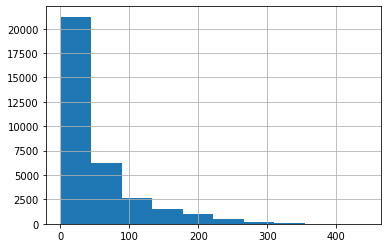

In [30]:
dataset_grouped.mosq_pred.hist()

In [31]:
dataset_grouped = convert_temperature(dataset_grouped)

<AxesSubplot:>

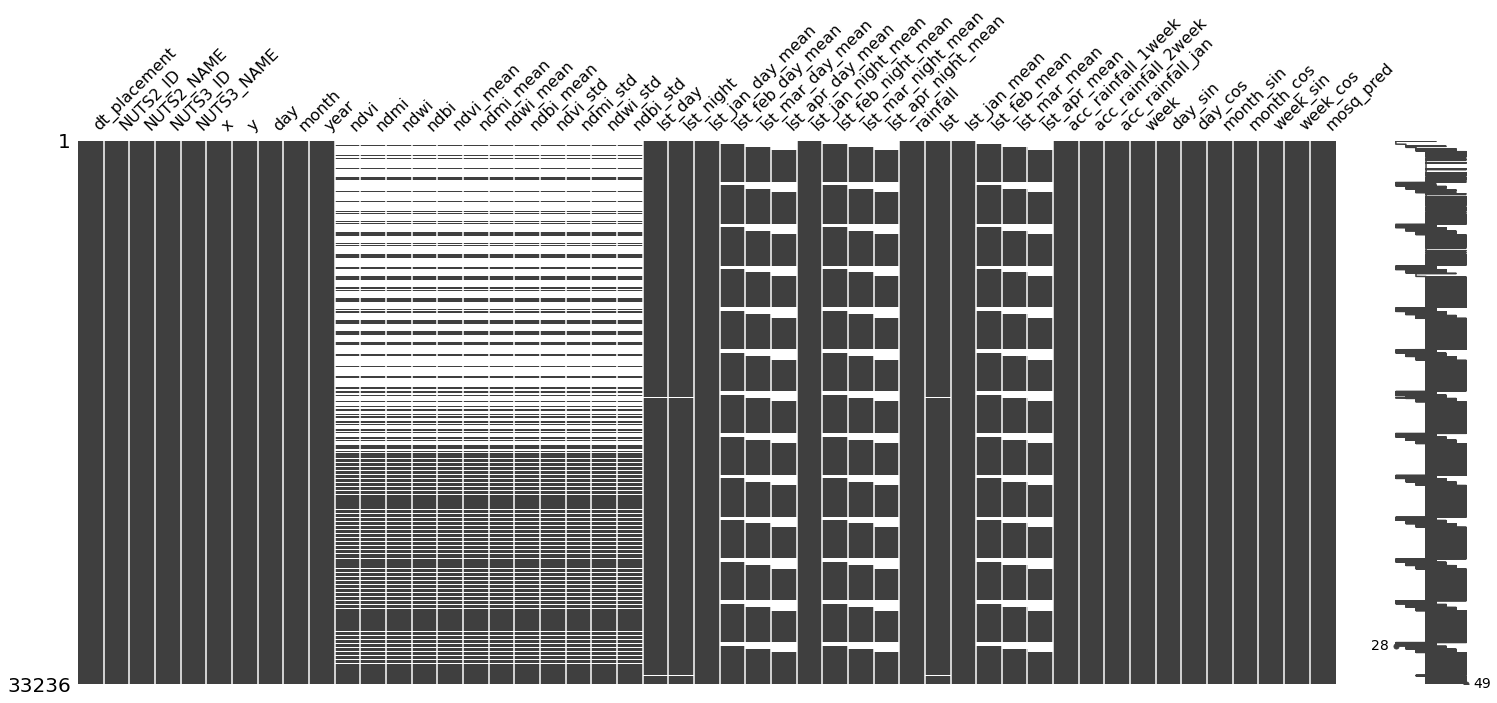

In [32]:
missingno.matrix(dataset_grouped)

### Add Bio Variables ###

In [33]:
bio_values = []

for region in dataset_grouped.NUTS3_NAME.unique():
    for year in dataset_grouped.year.unique():
        for month in dataset_grouped.month.unique():
            filtered_df = dataset_grouped.loc[(dataset_grouped['year'] == year) & (dataset_grouped['NUTS3_NAME'] == region) & (dataset_grouped['month'] == month)].copy()
            tmin = min(filtered_df['lst_day'].min(), filtered_df['lst_night'].min())
            tmax = max(filtered_df['lst_day'].max(), filtered_df['lst_night'].max())
            prec = filtered_df['rainfall'].sum()
            bio_values.append({'NUTS3_NAME': region, 
                               'year': year, 
                               'month': month, 
                               'monthly_lst_min': tmin, 
                               'monthly_lst_max': tmax,
                               'monthly_acc_prec': prec})

In [34]:
bio_values_df = pd.DataFrame(bio_values)

In [35]:
dataset = pd.merge(dataset_grouped, bio_values_df, on=['NUTS3_NAME', 'year', 'month'], how='left')

In [36]:
dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred,monthly_lst_min,monthly_lst_max,monthly_acc_prec
0,2010-01-01,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.812763,38.047451,1.000000,1.000000,2010.000000,0.238709,0.125007,-0.093093,-0.125007,0.237988,0.124278,-0.095426,-0.124278,0.038738,0.029813,0.027037,0.029813,17.782222,11.792222,17.782222,NaN,NaN,NaN,11.792222,NaN,NaN,NaN,0.000000,14.787222,14.787222,NaN,NaN,NaN,0.000000,0.000000,0.000000,53.000000,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,147.388889,0.578889,17.782222,120.039680
1,2010-01-01,EL30,αττικη,EL302,δυτικος τομεας αθηνων,23.685082,38.018504,1.000000,1.000000,2010.000000,0.148037,0.048113,-0.115208,-0.048113,0.132420,0.041732,-0.098505,-0.041732,0.012587,0.012635,0.018510,0.012635,19.014444,12.590000,19.014444,NaN,NaN,NaN,12.590000,NaN,NaN,NaN,0.000000,15.802222,15.802222,NaN,NaN,NaN,0.000000,0.000000,0.000000,53.000000,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,187.444444,1.052222,19.014444,112.130405
2,2010-01-01,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.754944,37.979104,1.000000,1.000000,2010.000000,0.199024,0.129720,-0.038309,-0.129720,0.183807,0.120342,-0.036695,-0.120342,0.056233,0.037885,0.038611,0.037885,18.605789,12.751111,18.605789,NaN,NaN,NaN,12.751111,NaN,NaN,NaN,0.000000,15.678450,15.653889,NaN,NaN,NaN,0.000000,0.000000,0.000000,53.000000,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,152.263158,0.379474,18.605789,112.993420
3,2010-01-01,EL30,αττικη,EL304,νοτιος τομεας αθηνων,23.749555,37.914897,1.000000,1.000000,2010.000000,0.221100,0.092933,-0.119241,-0.092933,0.205771,0.089282,-0.109884,-0.089282,0.036622,0.016738,0.032846,0.016738,19.224000,13.222000,19.224000,NaN,NaN,NaN,13.222000,NaN,NaN,NaN,0.000000,16.223000,16.223000,NaN,NaN,NaN,0.000000,0.000000,0.000000,53.000000,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,169.400000,-2.668000,19.224000,110.246915
4,2010-01-01,EL30,αττικη,EL305,ανατολικη αττικη,23.889386,38.042726,1.000000,1.000000,2010.000000,0.397771,0.155384,-0.199277,-0.155384,0.399240,0.160357,-0.193923,-0.160357,0.037753,0.035591,0.039219,0.035591,18.574390,11.846828,18.574390,NaN,NaN,NaN,11.846828,NaN,NaN,NaN,0.000000,15.210609,15.226794,NaN,NaN,NaN,0.000000,0.000000,0.000000,53.000000,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,145.734483,1.772276,18.574390,121.070102
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33231,2022-12-31,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.754944,37.979104,31.000000,12.000000,2022.000000,0.178418,0.099457,-0.147676,-0.099457,0.185629,0.089411,-0.156381,-0.089411,0.072370,0.051394,0.059634,0.051394,14.914211,9.070000,10.264160,14.369662,16.211800,16.211800,5.078523,7.168609,5.180017,5.180017,0.000000,11.992105,7.671341,10.769135,10.695908,10.695908,0.000000,0.223181,806.912175,52.000000,-0.000000,1.000000,-0.000000,1.000000,-0.118273,0.992981,3.736842,4.714211,18.715263,67.406213
33232,2022-12-31,EL30,αττικη,EL304,νοτιος τομεας αθηνων,23.749555,37.914897,31.000000,12.000000,2022.000000,0.219922,0.081568,-0.205440,-0.081568,0.190039,0.060106,-0.184211,-0.060106,0.047047,0.035390,0.038127,0.035390,15.320000,9.654000,10.982129,14.565286,16.616968,16.616968,4.807871,7.100643,5.210129,5.210129,0.000000,12.487000,7.895000,10.832964,10.913548,10.913548,0.000000,0.179486,763.507585,52.000000,-0.000000,1.000000,-0.000000,1.0000

<AxesSubplot:>

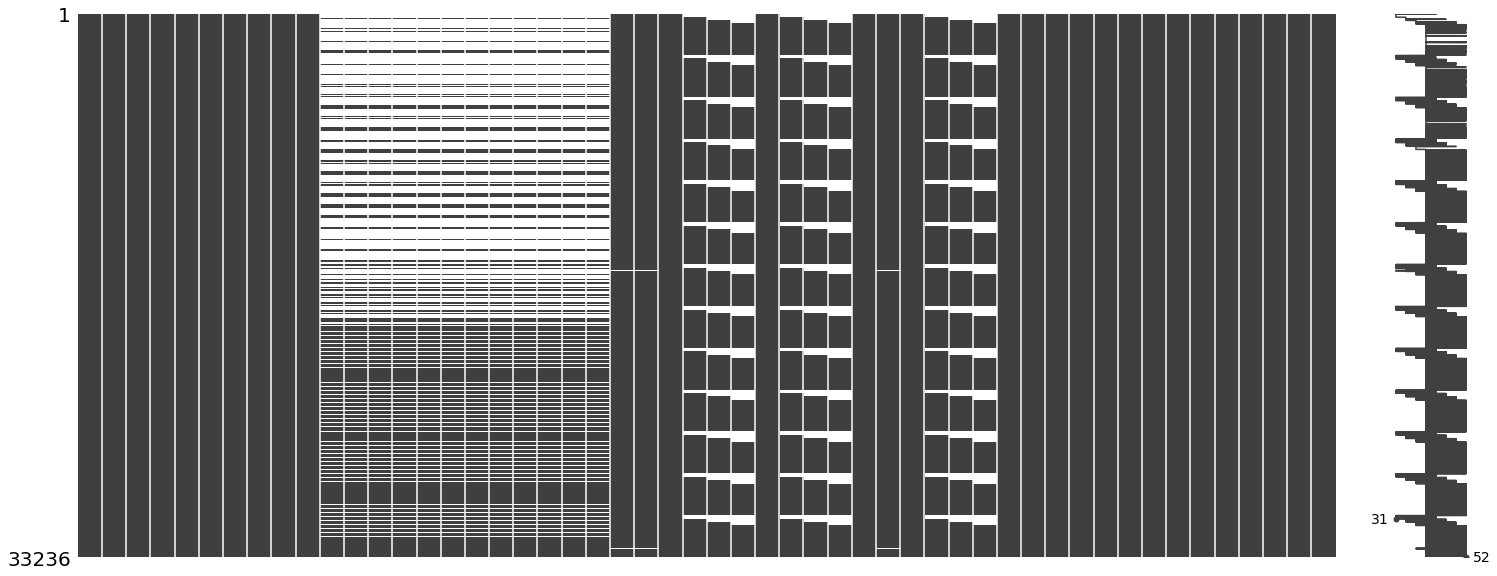

In [37]:
missingno.matrix(dataset)

In [38]:
dataset = dataset.astype({"day":"int","month":"int", "year":"int"})

In [39]:
dataset.rename(columns={"dt_placement": "dt_placement_daily"}, inplace=True)

In [40]:
dataset['date_string'] = dataset['month'].astype(str) + '-' + dataset['year'].astype(str)
dataset['dt_placement'] = pd.to_datetime(dataset['date_string'], format='%m-%Y').dt.to_period('M')
dataset.drop(columns=['date_string'], inplace = True)

In [41]:
dataset

,dt_placement_daily,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred,monthly_lst_min,monthly_lst_max,monthly_acc_prec,dt_placement
0,2010-01-01,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.812763,38.047451,1,1,2010,0.238709,0.125007,-0.093093,-0.125007,0.237988,0.124278,-0.095426,-0.124278,0.038738,0.029813,0.027037,0.029813,17.782222,11.792222,17.782222,NaN,NaN,NaN,11.792222,NaN,NaN,NaN,0.000000,14.787222,14.787222,NaN,NaN,NaN,0.000000,0.000000,0.000000,53.000000,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,147.388889,0.578889,17.782222,120.039680,2010-01
1,2010-01-01,EL30,αττικη,EL302,δυτικος τομεας αθηνων,23.685082,38.018504,1,1,2010,0.148037,0.048113,-0.115208,-0.048113,0.132420,0.041732,-0.098505,-0.041732,0.012587,0.012635,0.018510,0.012635,19.014444,12.590000,19.014444,NaN,NaN,NaN,12.590000,NaN,NaN,NaN,0.000000,15.802222,15.802222,NaN,NaN,NaN,0.000000,0.000000,0.000000,53.000000,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,187.444444,1.052222,19.014444,112.130405,2010-01
2,2010-01-01,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.754944,37.979104,1,1,2010,0.199024,0.129720,-0.038309,-0.129720,0.183807,0.120342,-0.036695,-0.120342,0.056233,0.037885,0.038611,0.037885,18.605789,12.751111,18.605789,NaN,NaN,NaN,12.751111,NaN,NaN,NaN,0.000000,15.678450,15.653889,NaN,NaN,NaN,0.000000,0.000000,0.000000,53.000000,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,152.263158,0.379474,18.605789,112.993420,2010-01
3,2010-01-01,EL30,αττικη,EL304,νοτιος τομεας αθηνων,23.749555,37.914897,1,1,2010,0.221100,0.092933,-0.119241,-0.092933,0.205771,0.089282,-0.109884,-0.089282,0.036622,0.016738,0.032846,0.016738,19.224000,13.222000,19.224000,NaN,NaN,NaN,13.222000,NaN,NaN,NaN,0.000000,16.223000,16.223000,NaN,NaN,NaN,0.000000,0.000000,0.000000,53.000000,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,169.400000,-2.668000,19.224000,110.246915,2010-01
4,2010-01-01,EL30,αττικη,EL305,ανατολικη αττικη,23.889386,38.042726,1,1,2010,0.397771,0.155384,-0.199277,-0.155384,0.399240,0.160357,-0.193923,-0.160357,0.037753,0.035591,0.039219,0.035591,18.574390,11.846828,18.574390,NaN,NaN,NaN,11.846828,NaN,NaN,NaN,0.000000,15.210609,15.226794,NaN,NaN,NaN,0.000000,0.000000,0.000000,53.000000,0.201299,0.979530,0.500000,0.866025,-0.000000,1.000000,145.734483,1.772276,18.574390,121.070102,2010-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33231,2022-12-31,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.754944,37.979104,31,12,2022,0.178418,0.099457,-0.147676,-0.099457,0.185629,0.089411,-0.156381,-0.089411,0.072370,0.051394,0.059634,0.051394,14.914211,9.070000,10.264160,14.369662,16.211800,16.211800,5.078523,7.168609,5.180017,5.180017,0.000000,11.992105,7.671341,10.769135,10.695908,10.695908,0.000000,0.223181,806.912175,52.000000,-0.000000,1.000000,-0.000000,1.000000,-0.118273,0.992981,3.736842,4.714211,18.715263,67.406213,2022-12
33232,2022-12-31,EL30,αττικη,EL304,νοτιος τομεας αθηνων,23.749555,37.914897,31,12,2022,0.219922,0.081568,-0.205440,-0.081568,0.190039,0.060106,-0.184211,-0.060106,0.047047,0.035390,0.038127,0.035390,15.320000,9.654000,10.982129,14.565286,16.616968,16.616968,4.807871,7.100643,5.210129,5.210129,0.000000,12.487000,7.895000,10.832964,10.913548,10.913548,0.000000,0.179486,763.507585,52.000000,-0.000000,1.000000,-0.000000,1.000000,-0.118273,0.992981,7.000000,4.638000,19.234000,74.734505,2022-12
33233,20

In [42]:
grouped = dataset.groupby(['dt_placement', 'NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME'], as_index = False)
grouped_mosq = dataset.groupby(['dt_placement', 'NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME'], as_index = False)


dataset_month = grouped.mean()
dataset_month_mosq = grouped.sum()


dataset_month

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred,monthly_lst_min,monthly_lst_max,monthly_acc_prec
0,2010-01,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.812763,38.047451,16.000000,1.000000,2010.000000,0.238709,0.125007,-0.093093,-0.125007,0.237988,0.124278,-0.095426,-0.124278,0.038738,0.029813,0.027037,0.029813,11.580251,5.941828,13.594339,NaN,NaN,NaN,7.872031,NaN,NaN,NaN,3.872248,8.761039,10.733185,NaN,NaN,NaN,25.307650,42.361009,47.792020,7.387097,-0.000000,-0.000000,0.500000,0.866025,0.261482,0.953050,69.835125,0.578889,17.782222,120.039680
1,2010-01,EL30,αττικη,EL302,δυτικος τομεας αθηνων,23.685082,38.018504,16.000000,1.000000,2010.000000,0.148037,0.048113,-0.115208,-0.048113,0.132420,0.041732,-0.098505,-0.041732,0.012587,0.012635,0.018510,0.012635,13.860538,7.126918,16.635552,NaN,NaN,NaN,9.236196,NaN,NaN,NaN,3.617110,10.493728,12.935874,NaN,NaN,NaN,23.686240,39.818155,44.482084,7.387097,-0.000000,-0.000000,0.500000,0.866025,0.261482,0.953050,83.770609,1.052222,19.014444,112.130405
2,2010-01,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.754944,37.979104,16.000000,1.000000,2010.000000,0.199024,0.129720,-0.038309,-0.129720,0.183807,0.120342,-0.036695,-0.120342,0.056233,0.037885,0.038611,0.037885,12.876044,6.630647,14.995668,NaN,NaN,NaN,8.808187,NaN,NaN,NaN,3.644949,9.753346,11.901135,NaN,NaN,NaN,23.831676,39.924151,44.652948,7.387097,-0.000000,-0.000000,0.500000,0.866025,0.261482,0.953050,76.629881,0.379474,18.605789,112.993420
3,2010-01,EL30,αττικη,EL304,νοτιος τομεας αθηνων,23.749555,37.914897,16.000000,1.000000,2010.000000,0.221100,0.092933,-0.119241,-0.092933,0.205771,0.089282,-0.109884,-0.089282,0.036622,0.016738,0.032846,0.016738,12.310000,5.834968,14.676866,NaN,NaN,NaN,8.763849,NaN,NaN,NaN,3.556352,9.072484,11.720357,NaN,NaN,NaN,23.460094,39.829571,44.335911,7.387097,-0.000000,-0.000000,0.500000,0.866025,0.261482,0.953050,79.625806,-2.668000,19.224000,110.246915
4,2010-01,EL30,αττικη,EL305,ανατολικη αττικη,23.889386,38.042726,16.000000,1.000000,2010.000000,0.397771,0.155384,-0.199277,-0.155384,0.399240,0.160357,-0.193923,-0.160357,0.037753,0.035591,0.039219,0.035591,11.589957,5.813515,13.768236,NaN,NaN,NaN,7.672467,NaN,NaN,NaN,3.905487,8.701736,10.720874,NaN,NaN,NaN,25.460487,41.766648,46.576365,7.387097,-0.000000,-0.000000,0.500000,0.866025,0.261482,0.953050,67.704894,1.772276,18.574390,121.070102
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1087,2022-12,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.754944,37.979104,16.000000,12.000000,2022.000000,0.162913,0.095954,-0.134227,-0.095954,0.167547,0.091249,-0.138857,-0.091249,0.059392,0.043344,0.051238,0.043344,14.901511,9.690238,10.264160,14.369662,16.211800,16.211800,5.078523,7.168609,5.180017,5.180017,2.174394,12.295874,7.671341,10.769135,10.695908,10.695908,37.736958,91.161122,784.062436,50.129032,-0.000000,-0.000000,-0.000000,1.000000,-0.329750,0.931265,5.614601,4.714211,18.715263,67.406213
1088,2022-12,EL30,αττικη,EL304,νοτιος τομεας αθηνων,23.749555,37.914897,16.000000,12.000000,2022.000000,0.198873,0.085134,-0.182033,-0.085134,0.159183,0.069906,-0.147654,-0.069906,0.038011,0.030059,0.035878,0.030059,15.492968,9.377935,10.982129,14.565286,16.616968,16.616968,4.807871,7.100643,5.210129,5.210129,2.410790,12.435452,7.895000,10.832964,10.913548,10.913548,40.237718,95.783340,739.342486,50.129032,-0.000000,-0.000000,-0.000000,1.000000,-0.329750,0.9

In [43]:
dataset_month_mosq

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred,monthly_lst_min,monthly_lst_max,monthly_acc_prec
0,2010-01,EL30,αττικη,EL301,βορειος τομεας αθηνων,738.195663,1179.470984,496,31,62310,0.477418,0.250014,-0.186185,-0.250014,0.475976,0.248556,-0.190851,-0.248556,0.077475,0.059626,0.054074,0.059626,358.987778,184.196667,421.424509,0.000000,0.000000,0.000000,244.032973,0.000000,0.000000,0.000000,120.039680,271.592222,332.728741,0.000000,0.000000,0.000000,784.537157,1313.191292,1481.552611,229.000000,-0.000000,-0.000000,15.500000,26.846788,8.105931,29.544565,2164.888889,17.945556,551.248889,3721.230068
1,2010-01,EL30,αττικη,EL302,δυτικος τομεας αθηνων,734.237549,1178.573638,496,31,62310,0.296074,0.096225,-0.230416,-0.096225,0.264839,0.083465,-0.197010,-0.083465,0.025174,0.025269,0.037020,0.025269,429.676667,220.934444,515.702104,0.000000,0.000000,0.000000,286.322071,0.000000,0.000000,0.000000,112.130405,325.305556,401.012087,0.000000,0.000000,0.000000,734.273432,1234.362816,1378.944603,229.000000,-0.000000,-0.000000,15.500000,26.846788,8.105931,29.544565,2596.888889,32.618889,589.447778,3476.042551
2,2010-01,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,736.403271,1177.352214,496,31,62310,0.398048,0.259441,-0.076618,-0.259441,0.367615,0.240684,-0.073390,-0.240684,0.112465,0.075770,0.077221,0.075770,399.157368,205.550058,464.865709,0.000000,0.000000,0.000000,273.053794,0.000000,0.000000,0.000000,112.993420,302.353713,368.935190,0.000000,0.000000,0.000000,738.781964,1237.648687,1384.241394,229.000000,-0.000000,-0.000000,15.500000,26.846788,8.105931,29.544565,2375.526316,11.763684,576.779474,3502.796012
3,2010-01,EL30,αττικη,EL304,νοτιος τομεας αθηνων,736.236205,1175.361807,496,31,62310,0.442200,0.185866,-0.238482,-0.185866,0.411541,0.178563,-0.219767,-0.178563,0.073244,0.033475,0.065692,0.033475,381.610000,180.884000,454.982851,0.000000,0.000000,0.000000,271.679312,0.000000,0.000000,0.000000,110.246915,281.247000,363.331082,0.000000,0.000000,0.000000,727.262899,1234.716697,1374.413244,229.000000,-0.000000,-0.000000,15.500000,26.846788,8.105931,29.544565,2468.400000,-82.708000,595.944000,3417.654353
4,2010-01,EL30,αττικη,EL305,ανατολικη αττικη,740.570962,1179.324521,496,31,62310,0.795541,0.310767,-0.398554,-0.310767,0.798481,0.320715,-0.387846,-0.320715,0.075505,0.071183,0.078438,0.071183,359.288666,180.218966,426.815315,0.000000,0.000000,0.000000,237.846491,0.000000,0.000000,0.000000,121.070102,269.753816,332.347088,0.000000,0.000000,0.000000,789.275101,1294.766080,1443.867320,229.000000,-0.000000,-0.000000,15.500000,26.846788,8.105931,29.544565,2098.851724,54.940552,575.806098,3753.173158
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1087,2022-12,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,736.403271,1177.352214,496,372,62682,4.072824,2.398860,-3.355663,-2.398860,4.188670,2.281232,-3.471414,-2.281232,1.484808,1.083610,1.280950,1.083610,461.946842,300.397368,318.188947,445.459511,502.565789,502.565789,157.434211,222.226880,160.580526,160.580526,67.406213,381.172105,237.811579,333.843195,331.573158,331.573158,1169.845688,2825.994773,24305.935506,1554.000000,-0.000000,-0.000000,-0.000000,31.000000,-10.222245,28.869207,174.052632,146.140526,580.173158,2089.592599
1088,2022-12,EL30,αττικη,EL304,νοτιος τομεας αθηνων,736.236205,1175.361807,496,372,62682,4.971813,2.128347,-4.550819,-2.128347,3.979577,1.747659,-3.691338,-1.

In [44]:
dataset_month['mosq_pred'] = dataset_month_mosq['mosq_pred']

In [45]:
wnv_file.head(5)

,NUTS2_NAME,NUTS3_NAME,dt_placement,cases
0,αττικη,ανατολικη αττικη,2011-05,0
1,αττικη,ανατολικη αττικη,2011-06,0
2,αττικη,ανατολικη αττικη,2011-07,7
3,αττικη,ανατολικη αττικη,2011-08,8
4,αττικη,ανατολικη αττικη,2011-09,5


In [46]:
dataset_month.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1092 entries, 0 to 1091
Data columns (total 52 columns):
 #   Column              Non-Null Count  Dtype    
---  ------              --------------  -----    
 0   dt_placement        1092 non-null   period[M]
 1   NUTS2_ID            1092 non-null   object   
 2   NUTS2_NAME          1092 non-null   object   
 3   NUTS3_ID            1092 non-null   object   
 4   NUTS3_NAME          1092 non-null   object   
 5   x                   1092 non-null   float64  
 6   y                   1092 non-null   float64  
 7   day                 1092 non-null   float64  
 8   month               1092 non-null   float64  
 9   year                1092 non-null   float64  
 10  ndvi                1078 non-null   float64  
 11  ndmi                1078 non-null   float64  
 12  ndwi                1078 non-null   float64  
 13  ndbi                1078 non-null   float64  
 14  ndvi_mean           1081 non-null   float64  
 15  ndmi_mean           1

In [47]:
wnv_file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336 entries, 0 to 335
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   NUTS2_NAME    336 non-null    object
 1   NUTS3_NAME    336 non-null    object
 2   dt_placement  336 non-null    object
 3   cases         336 non-null    int64 
dtypes: int64(1), object(3)
memory usage: 10.6+ KB


In [48]:
wnv_file['dt_placement'] = pd.to_datetime(wnv_file['dt_placement'], format='%Y-%m').dt.to_period('M')

In [49]:
wnv_file

,NUTS2_NAME,NUTS3_NAME,dt_placement,cases
0,αττικη,ανατολικη αττικη,2011-05,0
1,αττικη,ανατολικη αττικη,2011-06,0
2,αττικη,ανατολικη αττικη,2011-07,7
3,αττικη,ανατολικη αττικη,2011-08,8
4,αττικη,ανατολικη αττικη,2011-09,5
...,...,...,...,...
331,αττικη,"πειραιας, νησοι",2021-06,0
332,αττικη,"πειραιας, νησοι",2021-07,0
333,αττικη,"πειραιας, νησοι",2021-08,0
334,αττικη,"πειραιας, νησοι",2021-09,0


In [50]:
wnv_file['cases'].value_counts()

0     269
1      35
4       5
8       4
5       4
7       3
2       3
6       2
3       2
11      1
15      1
10      1
18      1
16      1
12      1
33      1
9       1
20      1
Name: cases, dtype: int64

In [51]:
wnv_file.cases.sum()

296

In [52]:
merged = dataset_month.merge(wnv_file, how='left', on=['dt_placement', 'NUTS3_NAME', 'NUTS2_NAME'] )

In [53]:
merged

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases
0,2010-01,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.812763,38.047451,16.000000,1.000000,2010.000000,0.238709,0.125007,-0.093093,-0.125007,0.237988,0.124278,-0.095426,-0.124278,0.038738,0.029813,0.027037,0.029813,11.580251,5.941828,13.594339,NaN,NaN,NaN,7.872031,NaN,NaN,NaN,3.872248,8.761039,10.733185,NaN,NaN,NaN,25.307650,42.361009,47.792020,7.387097,-0.000000,-0.000000,0.500000,0.866025,0.261482,0.953050,2164.888889,0.578889,17.782222,120.039680,NaN
1,2010-01,EL30,αττικη,EL302,δυτικος τομεας αθηνων,23.685082,38.018504,16.000000,1.000000,2010.000000,0.148037,0.048113,-0.115208,-0.048113,0.132420,0.041732,-0.098505,-0.041732,0.012587,0.012635,0.018510,0.012635,13.860538,7.126918,16.635552,NaN,NaN,NaN,9.236196,NaN,NaN,NaN,3.617110,10.493728,12.935874,NaN,NaN,NaN,23.686240,39.818155,44.482084,7.387097,-0.000000,-0.000000,0.500000,0.866025,0.261482,0.953050,2596.888889,1.052222,19.014444,112.130405,NaN
2,2010-01,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.754944,37.979104,16.000000,1.000000,2010.000000,0.199024,0.129720,-0.038309,-0.129720,0.183807,0.120342,-0.036695,-0.120342,0.056233,0.037885,0.038611,0.037885,12.876044,6.630647,14.995668,NaN,NaN,NaN,8.808187,NaN,NaN,NaN,3.644949,9.753346,11.901135,NaN,NaN,NaN,23.831676,39.924151,44.652948,7.387097,-0.000000,-0.000000,0.500000,0.866025,0.261482,0.953050,2375.526316,0.379474,18.605789,112.993420,NaN
3,2010-01,EL30,αττικη,EL304,νοτιος τομεας αθηνων,23.749555,37.914897,16.000000,1.000000,2010.000000,0.221100,0.092933,-0.119241,-0.092933,0.205771,0.089282,-0.109884,-0.089282,0.036622,0.016738,0.032846,0.016738,12.310000,5.834968,14.676866,NaN,NaN,NaN,8.763849,NaN,NaN,NaN,3.556352,9.072484,11.720357,NaN,NaN,NaN,23.460094,39.829571,44.335911,7.387097,-0.000000,-0.000000,0.500000,0.866025,0.261482,0.953050,2468.400000,-2.668000,19.224000,110.246915,NaN
4,2010-01,EL30,αττικη,EL305,ανατολικη αττικη,23.889386,38.042726,16.000000,1.000000,2010.000000,0.397771,0.155384,-0.199277,-0.155384,0.399240,0.160357,-0.193923,-0.160357,0.037753,0.035591,0.039219,0.035591,11.589957,5.813515,13.768236,NaN,NaN,NaN,7.672467,NaN,NaN,NaN,3.905487,8.701736,10.720874,NaN,NaN,NaN,25.460487,41.766648,46.576365,7.387097,-0.000000,-0.000000,0.500000,0.866025,0.261482,0.953050,2098.851724,1.772276,18.574390,121.070102,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1087,2022-12,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.754944,37.979104,16.000000,12.000000,2022.000000,0.162913,0.095954,-0.134227,-0.095954,0.167547,0.091249,-0.138857,-0.091249,0.059392,0.043344,0.051238,0.043344,14.901511,9.690238,10.264160,14.369662,16.211800,16.211800,5.078523,7.168609,5.180017,5.180017,2.174394,12.295874,7.671341,10.769135,10.695908,10.695908,37.736958,91.161122,784.062436,50.129032,-0.000000,-0.000000,-0.000000,1.000000,-0.329750,0.931265,174.052632,4.714211,18.715263,67.406213,NaN
1088,2022-12,EL30,αττικη,EL304,νοτιος τομεας αθηνων,23.749555,37.914897,16.000000,12.000000,2022.000000,0.198873,0.085134,-0.182033,-0.085134,0.159183,0.069906,-0.147654,-0.069906,0.038011,0.030059,0.035878,0.030059,15.492968,9.377935,10.982129,14.565286,16.616968,16.616968,4.807871,7.100643,5.210129,5.210129,2.410790,12.435452,7.895000,10.832964,10.913548,10.913548,40.237718,95.783340,739.342486,50.129032,-0.000

In [54]:
merged = fillna(merged,{'cases': 0})

In [55]:
merged['cases'].value_counts()

0.000000     1025
1.000000       35
4.000000        5
8.000000        4
5.000000        4
7.000000        3
2.000000        3
6.000000        2
3.000000        2
10.000000       1
33.000000       1
18.000000       1
9.000000        1
16.000000       1
20.000000       1
15.000000       1
12.000000       1
11.000000       1
Name: cases, dtype: int64

In [56]:
merged.cases.sum()

296.0

In [57]:
merged = merged.astype({'day':'int', 'month':'int', 'year':'int', 'cases': 'int'})

In [58]:
merged.drop(columns=['day'], inplace=True)

<AxesSubplot:>

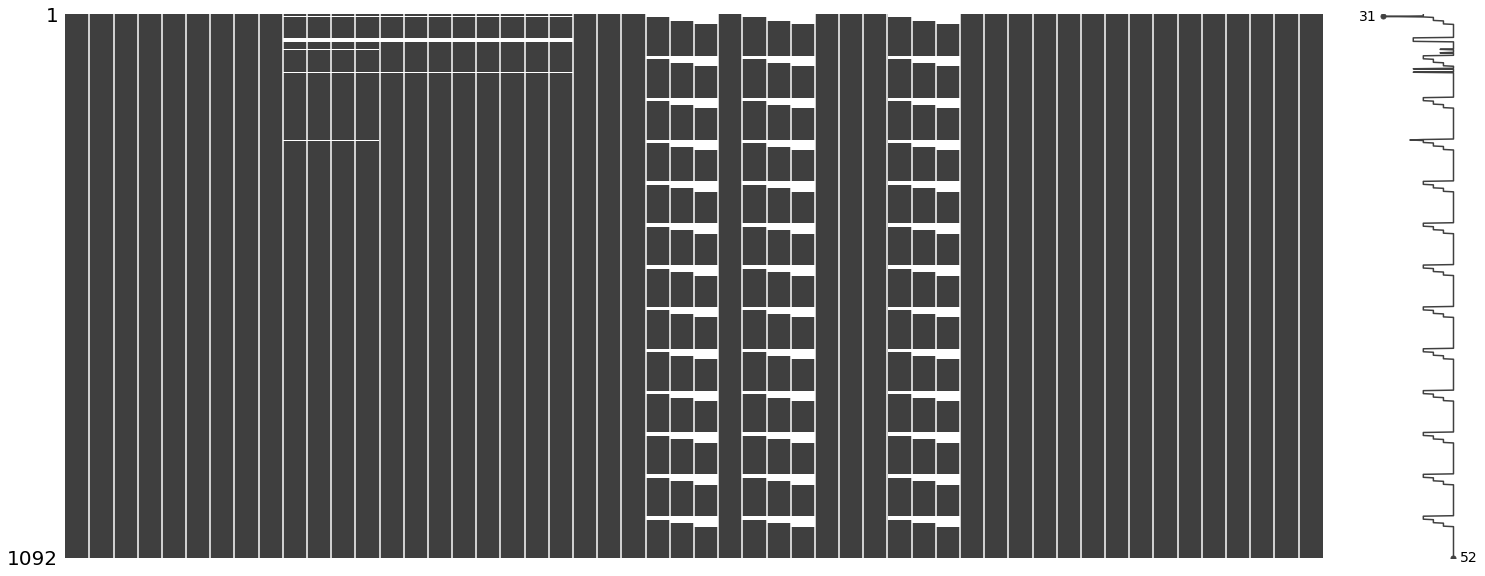

In [59]:
missingno.matrix(merged)

In [60]:
missing = describe_dataframe(merged)
missing

,Column,Missing
0,dt_placement,0.000000
1,NUTS2_ID,0.000000
2,NUTS2_NAME,0.000000
3,NUTS3_ID,0.000000
4,NUTS3_NAME,0.000000
5,x,0.000000
6,y,0.000000
7,month,0.000000
8,year,0.000000
9,ndvi,1.282100


In [61]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'month', 'year', 'monthly_lst_min', 'monthly_lst_max']

temp_df = merged[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['monthly_lst_min', 'monthly_lst_max']

merged[imputed_columns] = imputed_data[imputed_columns]

In [62]:
missing = describe_dataframe(merged)
missing

,Column,Missing
0,dt_placement,0.000000
1,NUTS2_ID,0.000000
2,NUTS2_NAME,0.000000
3,NUTS3_ID,0.000000
4,NUTS3_NAME,0.000000
5,x,0.000000
6,y,0.000000
7,month,0.000000
8,year,0.000000
9,ndvi,1.282100


In [63]:
years = merged.year.unique()
years

array([2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020,
       2021, 2022])

In [64]:
nuts3_units = merged.NUTS3_NAME.unique()
nuts3_units

array(['βορειος τομεας αθηνων', 'δυτικος τομεας αθηνων',
       'κεντρικος τομεας αθηνων', 'νοτιος τομεας αθηνων',
       'ανατολικη αττικη', 'δυτικη αττικη', 'πειραιας, νησοι'],
      dtype=object)

In [65]:
rows = []
for year in years:
    for region in nuts3_units:
        filtered_df = merged.loc[(merged['year'] == year) & (merged['NUTS3_NAME'] == region)].copy()
        filtered_df.reset_index(drop = True, inplace = True)

        tmin = robjects.IntVector(filtered_df['monthly_lst_min'].tolist())
        tmax = robjects.IntVector(filtered_df['monthly_lst_max'].tolist())
        prec = robjects.IntVector(filtered_df['monthly_acc_prec'].tolist())

        bio_vars = list(dismo.biovars(prec, tmin, tmax))

        rows.append({'NUTS3_NAME': region, 
                     'year': year, 
                     'bio1': bio_vars[0],
                     'bio2': bio_vars[1],
                     'bio3': bio_vars[2],
                     'bio4': bio_vars[3],
                     'bio5': bio_vars[4],
                     'bio6': bio_vars[5],
                     'bio7': bio_vars[6],
                     'bio8': bio_vars[7],
                     'bio9': bio_vars[8],
                     'bio10': bio_vars[9],
                     'bio11': bio_vars[10],
                     'bio12': bio_vars[11],
                     'bio13': bio_vars[12],
                     'bio14': bio_vars[13],
                     'bio15': bio_vars[14],
                     'bio16': bio_vars[15],
                     'bio17': bio_vars[16],
                     'bio18': bio_vars[17],
                     'bio19': bio_vars[18]})
        
biovars_df = pd.DataFrame(rows)

In [66]:
biovars_df.head(20)

,NUTS3_NAME,year,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,βορειος τομεας αθηνων,2010,19.750000,20.000000,45.454545,859.836137,44.000000,0.000000,44.000000,14.833333,30.833333,30.833333,9.333333,843.000000,213.000000,0.000000,83.792957,346.000000,70.000000,70.000000,332.000000
1,δυτικος τομεας αθηνων,2010,21.333333,20.500000,45.555556,895.781359,46.000000,1.000000,45.000000,15.666667,32.833333,32.833333,10.500000,806.000000,204.000000,0.000000,83.719908,324.000000,59.000000,59.000000,308.000000
2,κεντρικος τομεας αθηνων,2010,20.458333,19.583333,44.507576,856.116584,44.000000,0.000000,44.000000,15.500000,31.500000,31.500000,10.000000,800.000000,199.000000,0.000000,85.292444,324.000000,54.000000,54.000000,321.000000
3,νοτιος τομεας αθηνων,2010,20.666667,19.500000,42.391304,866.637529,44.000000,-2.000000,46.000000,9.833333,31.500000,31.500000,9.833333,779.000000,192.000000,0.000000,86.033662,317.000000,46.000000,46.000000,317.000000
4,ανατολικη αττικη,2010,19.416667,21.000000,47.727273,855.685088,44.000000,0.000000,44.000000,14.500000,30.500000,30.500000,9.333333,868.000000,219.000000,0.000000,83.901842,363.000000,71.000000,71.000000,342.000000
5,δυτικη αττικη,2010,19.125000,21.083333,47.916667,867.369325,44.000000,0.000000,44.000000,19.333333,30.500000,30.500000,9.166667,846.000000,217.000000,0.000000,82.107010,343.000000,63.000000,63.000000,303.000000
6,"πειραιας, νησοι",2010,19.958333,18.250000,45.625000,788.110033,42.000000,2.000000,40.000000,15.833333,29.333333,30.000000,10.500000,1370.000000,362.000000,2.000000,88.219002,630.000000,95.000000,125.000000,511.000000
7,βορειος τομεας αθηνων,2011,18.166667,19.000000,45.238095,899.579026,42.000000,0.000000,42.000000,9.500000,29.500000,30.000000,8.500000,1240.000000,317.000000,0.000000,87.859478,635.000000,18.000000,79.000000,622.000000
8,δυτικος τομεας αθηνων,2011,19.500000,19.333333,42.962963,967.658843,43.000000,-2.000000,45.000000,9.333333,31.166667,32.166667,8.833333,1236.000000,326.000000,0.000000,89.842707,653.000000,23.000000,70.000000,630.000000
9,κεντρικος τομεας αθηνων,2011,19.041667,18.416667,42.829457,908.910020,42.000000,-1.000000,43.000000,9.666667,30.166667,30.666667,9.166667,1198.000000,310.000000,0.000000,89.519105,629.000000,20.000000,70.000000,612.000000


In [67]:
merged = pd.merge(merged, biovars_df,  how='left', on=['NUTS3_NAME', 'year'])

In [69]:
##check if biovars have the same value across all months
merged.loc[(merged['year'] == 2010) & (merged['NUTS3_NAME'] == 'δυτικη αττικη')]

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
5,2010-01,EL30,αττικη,EL306,δυτικη αττικη,23.393515,38.090792,1,2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.584146,4.510271,12.741392,NaN,NaN,NaN,6.649009,NaN,NaN,NaN,3.646743,7.547208,9.694744,NaN,NaN,NaN,23.488678,39.265744,43.997110,7.387097,-0.000000,-0.000000,0.500000,0.866025,0.261482,0.953050,2345.364583,-0.195625,18.126230,113.049047,0,19.125000,21.083333,47.916667,867.369325,44.000000,0.000000,44.000000,19.333333,30.500000,30.500000,9.166667,846.000000,217.000000,0.000000,82.107010,343.000000,63.000000,63.000000,303.000000
12,2010-02,EL30,αττικη,EL306,δυτικη αττικη,23.393515,38.090792,2,2010,0.308002,0.081885,-0.216865,-0.081885,0.302355,0.083829,-0.211749,-0.083829,0.022534,0.013486,0.016906,0.013486,12.437344,5.508661,10.583374,10.844476,NaN,NaN,4.508995,3.812675,NaN,NaN,4.175904,8.973002,7.546184,7.328575,NaN,NaN,30.942639,68.402023,193.627874,6.500000,0.021273,-0.103517,0.866025,0.500000,0.690447,0.711220,468.942708,-0.503021,17.528958,116.925310,0,19.125000,21.083333,47.916667,867.369325,44.000000,0.000000,44.000000,19.333333,30.500000,30.500000,9.166667,846.000000,217.000000,0.000000,82.107010,343.000000,63.000000,63.000000,303.000000
19,2010-03,EL30,αττικη,EL306,δυτικη αττικη,23.393515,38.090792,3,2010,0.365500,0.086692,-0.286407,-0.086692,0.366304,0.087960,-0.285143,-0.087960,0.032168,0.029559,0.026162,0.029559,17.719721,7.866250,10.583374,12.437344,16.966260,NaN,4.508995,5.508661,8.148393,NaN,2.329068,12.792986,7.546184,8.973002,12.557326,NaN,16.749192,35.118100,283.903163,10.741935,-0.000000,-0.000000,1.000000,0.000000,0.944883,0.289609,1112.166667,3.700000,22.775104,72.201094,0,19.125000,21.083333,47.916667,867.369325,44.000000,0.000000,44.000000,19.333333,30.500000,30.500000,9.166667,846.000000,217.000000,0.000000,82.107010,343.000000,63.000000,63.000000,303.000000
26,2010-04,EL30,αττικη,EL306,δυτικη αττικη,23.393515,38.090792,4,2010,0.386130,0.100389,-0.287597,-0.100389,0.383222,0.098423,-0.288289,-0.098423,0.033698,0.034967,0.030706,0.034967,21.909458,9.046431,10.583374,12.437344,17.719721,20.639266,4.508995,5.508661,7.866250,9.237416,0.427672,15.477944,7.546184,8.973002,12.792986,14.938341,2.923311,5.504504,310.256873,15.066667,0.000000,-0.033333,0.866025,-0.500000,0.965525,-0.211237,2377.453125,6.271563,27.701875,12.830148,0,19.125000,21.083333,47.916667,867.369325,44.000000,0.000000,44.000000,19.333333,30.500000,30.500000,9.166667,846.000000,217.000000,0.000000,82.107010,343.000000,63.000000,63.000000,303.000000
33,2010-05,EL30,αττικη,EL306,δυτικη αττικη,23.393515,38.090792,5,2010,0.358858,0.055140,-0.332241,-0.055140,0.361325,0.055838,-0.333667,-0.055838,0.034789,0.034002,0.025674,0.034002,30.695017,14.648239,10.583374,12.437344,17.719721,17.719721,4.508995,5.508661,7.866250,7.866250,1.711765,22.671628,7.546184,8.973002,12.792986,12.792986,11.459272,21.747840,340.002955,19.419355,-0.000000,-0.000000,0.500000,-0.866025,0.735239,-0.659841,4632.208333,11.502188,36.573021,53.064707,0,19.125000,21.083333,47.916667,867.369325,44.000000,0.000000,44.000000,19.333333,30.500000,30.500000,9.166667,846.000000,217.000000,0.000000,82.107010,343.000000,63.000000,63.000000,303.000000
40,2010-06,EL30,αττικη,EL306,δυτικη αττικη,23.393515,38.090792,6,2010,0.332308,0.030896,-0.331533,-0.030896,0.333100,0.030131,-0.333361,-0.030131,0.035268,0.034

In [70]:
df_demographics = pd.read_csv(f'../../data/{NUTS0}_EUROSTAT_Demographics_Processed.csv', encoding = enc)

In [71]:
df_demographics

,NUTS3_CODE,YEAR,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL
0,EL301,1991,51138.000000,165030.000000,25941.000000,242109.000000,48144.000000,183544.000000,33859.000000,265547.000000
1,EL301,1992,50517.000000,170015.000000,27446.000000,247978.000000,47283.000000,188320.000000,35622.000000,271225.000000
2,EL301,1993,49861.000000,173915.000000,28721.000000,252497.000000,46367.000000,192179.000000,37065.000000,275611.000000
3,EL301,1994,48815.000000,177441.000000,30222.000000,256478.000000,45313.000000,195444.000000,38973.000000,279730.000000
4,EL301,1995,47801.000000,180431.000000,31701.000000,259933.000000,44292.000000,198519.000000,40741.000000,283552.000000
...,...,...,...,...,...,...,...,...,...,...
1659,EL653,2018,16571.000000,78553.000000,29971.000000,125095.000000,16256.000000,75115.000000,32718.000000,124089.000000
1660,EL653,2019,16325.000000,78167.000000,30253.000000,124745.000000,16020.000000,74725.000000,32974.000000,123719.000000
1661,EL653,2020,16045.000000,77750.000000,30621.000000,124416.000000,15854.000000,74339.000000,33180.000000,123373.000000
1662,EL653,2021,15742.000000,77179.000000,31111.000000,124032.000000,15590.000000,73901.000000,33433.000000,122924.000000


In [72]:
df_demographics.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [73]:
df_demographics

,NUTS3_ID,year,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL
0,EL301,1991,51138.000000,165030.000000,25941.000000,242109.000000,48144.000000,183544.000000,33859.000000,265547.000000
1,EL301,1992,50517.000000,170015.000000,27446.000000,247978.000000,47283.000000,188320.000000,35622.000000,271225.000000
2,EL301,1993,49861.000000,173915.000000,28721.000000,252497.000000,46367.000000,192179.000000,37065.000000,275611.000000
3,EL301,1994,48815.000000,177441.000000,30222.000000,256478.000000,45313.000000,195444.000000,38973.000000,279730.000000
4,EL301,1995,47801.000000,180431.000000,31701.000000,259933.000000,44292.000000,198519.000000,40741.000000,283552.000000
...,...,...,...,...,...,...,...,...,...,...
1659,EL653,2018,16571.000000,78553.000000,29971.000000,125095.000000,16256.000000,75115.000000,32718.000000,124089.000000
1660,EL653,2019,16325.000000,78167.000000,30253.000000,124745.000000,16020.000000,74725.000000,32974.000000,123719.000000
1661,EL653,2020,16045.000000,77750.000000,30621.000000,124416.000000,15854.000000,74339.000000,33180.000000,123373.000000
1662,EL653,2021,15742.000000,77179.000000,31111.000000,124032.000000,15590.000000,73901.000000,33433.000000,122924.000000


In [74]:
dataset = pd.merge(merged, df_demographics,  how='left', on=['NUTS3_ID', 'year'])

<AxesSubplot:>

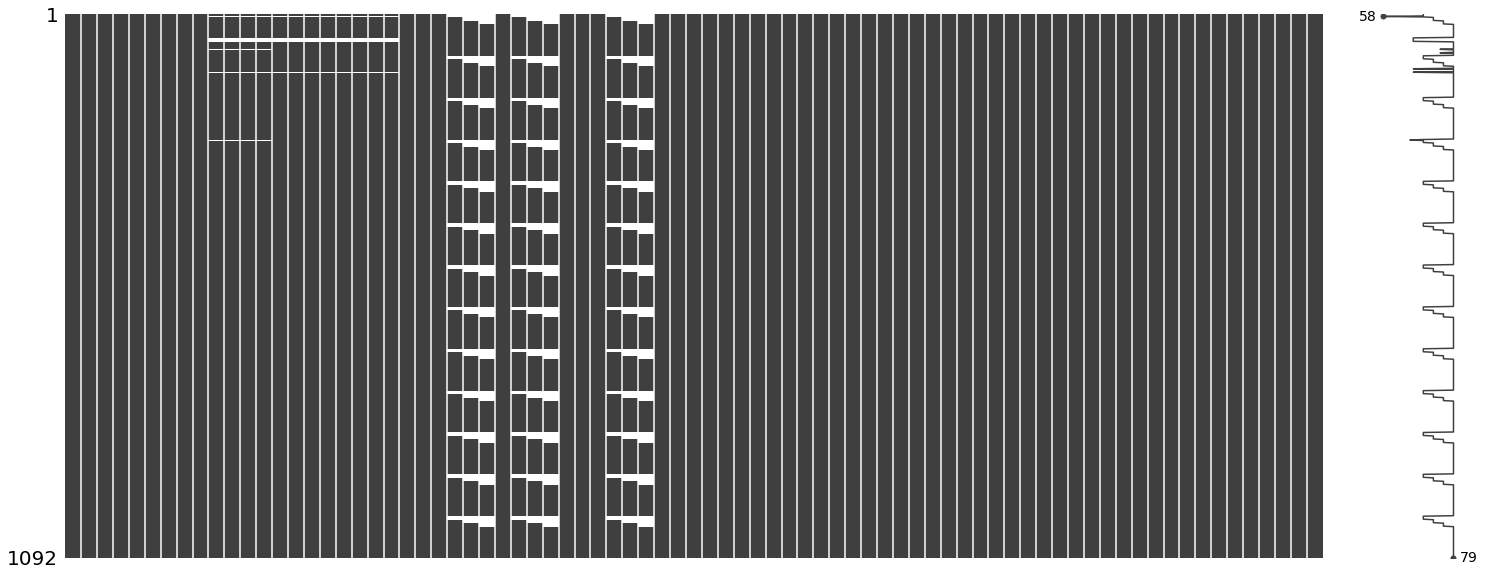

In [75]:
missingno.matrix(dataset)

In [76]:
df_economics = pd.read_csv(f'../../data/{NUTS0}_EUROSTAT_Economics_Processed.csv', encoding = enc)

In [77]:
df_economics

,NUTS3_CODE,YEAR,MIO_EUR
0,EL301,2000,10002.350000
1,EL301,2001,10677.520000
2,EL301,2002,12022.340000
3,EL301,2003,12784.960000
4,EL301,2004,14149.980000
...,...,...,...
1087,EL653,2016,3040.690000
1088,EL653,2017,3112.330000
1089,EL653,2018,3111.770000
1090,EL653,2019,3210.420000


In [78]:
df_economics.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [79]:
df_economics

,NUTS3_ID,year,MIO_EUR
0,EL301,2000,10002.350000
1,EL301,2001,10677.520000
2,EL301,2002,12022.340000
3,EL301,2003,12784.960000
4,EL301,2004,14149.980000
...,...,...,...
1087,EL653,2016,3040.690000
1088,EL653,2017,3112.330000
1089,EL653,2018,3111.770000
1090,EL653,2019,3210.420000


In [80]:
dataset = pd.merge(dataset, df_economics,  how='left', on=['NUTS3_ID', 'year'])

<AxesSubplot:>

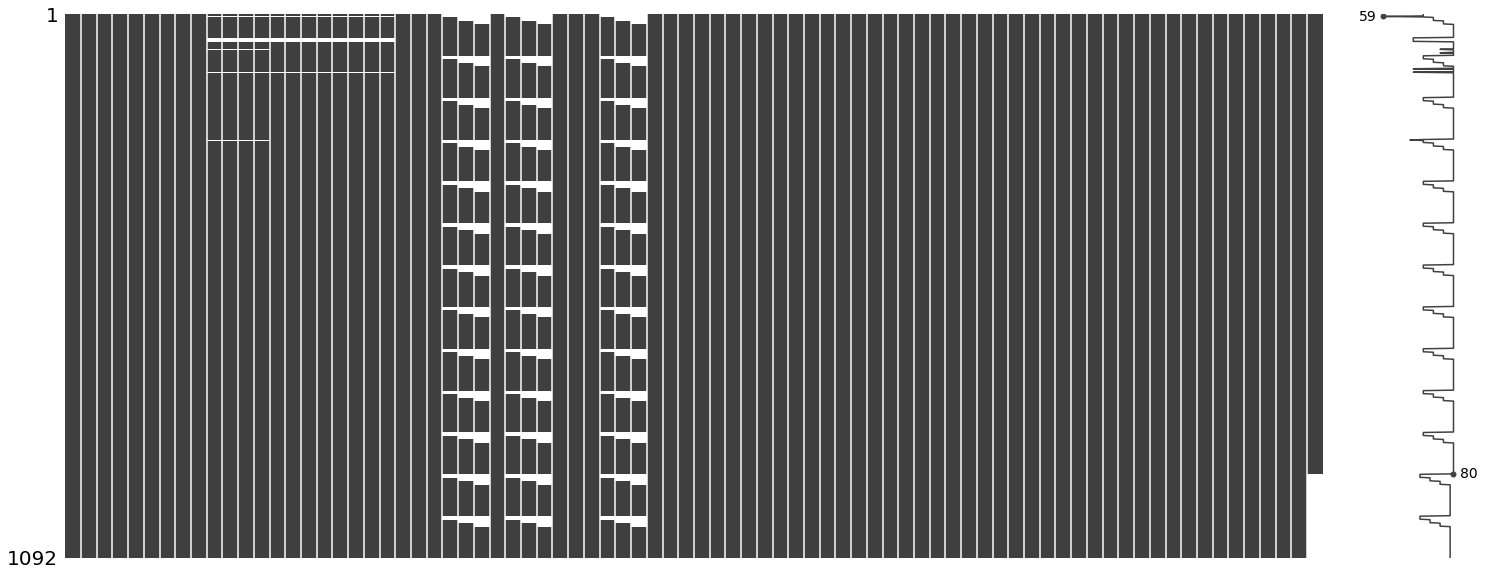

In [81]:
missingno.matrix(dataset)

In [82]:
df_trade = pd.read_csv(f'../../data/{NUTS0}_EUROSTAT_Trade_Processed.csv', encoding = enc)

In [83]:
df_trade

,NUTS3_CODE,YEAR,L_TOTAL,UNL_TOTAL
0,EL111,2008,6704.000000,7125.000000
1,EL111,2009,3031.000000,3303.000000
2,EL111,2010,2663.000000,2085.000000
3,EL111,2011,4163.000000,4212.000000
4,EL111,2012,4379.000000,5029.000000
...,...,...,...,...
714,EL653,2017,3065.000000,3506.000000
715,EL653,2018,2358.000000,2885.000000
716,EL653,2019,2914.000000,3549.000000
717,EL653,2020,4062.000000,4514.000000


In [84]:
df_trade.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [85]:
df_trade

,NUTS3_ID,year,L_TOTAL,UNL_TOTAL
0,EL111,2008,6704.000000,7125.000000
1,EL111,2009,3031.000000,3303.000000
2,EL111,2010,2663.000000,2085.000000
3,EL111,2011,4163.000000,4212.000000
4,EL111,2012,4379.000000,5029.000000
...,...,...,...,...
714,EL653,2017,3065.000000,3506.000000
715,EL653,2018,2358.000000,2885.000000
716,EL653,2019,2914.000000,3549.000000
717,EL653,2020,4062.000000,4514.000000


In [86]:
dataset = pd.merge(dataset, df_trade,  how='left', on=['NUTS3_ID', 'year'])

<AxesSubplot:>

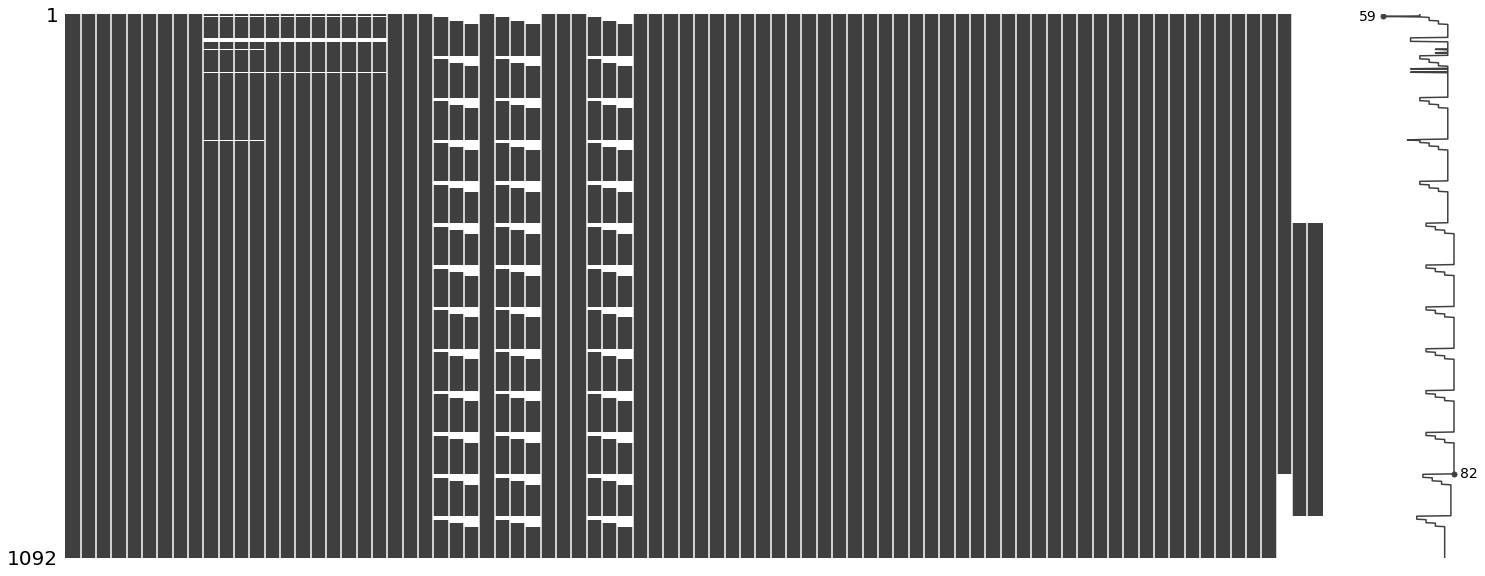

In [87]:
missingno.matrix(dataset)

In [88]:
missing = describe_dataframe(dataset)

In [89]:
missing

,Column,Missing
0,dt_placement,0.000000
1,NUTS2_ID,0.000000
2,NUTS2_NAME,0.000000
3,NUTS3_ID,0.000000
4,NUTS3_NAME,0.000000
5,x,0.000000
6,y,0.000000
7,month,0.000000
8,year,0.000000
9,ndvi,1.282100


In [90]:
dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,2010-01,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.812763,38.047451,1,2010,0.238709,0.125007,-0.093093,-0.125007,0.237988,0.124278,-0.095426,-0.124278,0.038738,0.029813,0.027037,0.029813,11.580251,5.941828,13.594339,NaN,NaN,NaN,7.872031,NaN,NaN,NaN,3.872248,8.761039,10.733185,NaN,NaN,NaN,25.307650,42.361009,47.792020,7.387097,-0.000000,-0.000000,0.500000,0.866025,0.261482,0.953050,2164.888889,0.578889,17.782222,120.039680,0,19.750000,20.000000,45.454545,859.836137,44.000000,0.000000,44.000000,14.833333,30.833333,30.833333,9.333333,843.000000,213.000000,0.000000,83.792957,346.000000,70.000000,70.000000,332.000000,45883.000000,200375.000000,47279.000000,293537.000000,43595.000000,220412.000000,60276.000000,324283.000000,18689.140000,NaN,NaN
1,2010-01,EL30,αττικη,EL302,δυτικος τομεας αθηνων,23.685082,38.018504,1,2010,0.148037,0.048113,-0.115208,-0.048113,0.132420,0.041732,-0.098505,-0.041732,0.012587,0.012635,0.018510,0.012635,13.860538,7.126918,16.635552,NaN,NaN,NaN,9.236196,NaN,NaN,NaN,3.617110,10.493728,12.935874,NaN,NaN,NaN,23.686240,39.818155,44.482084,7.387097,-0.000000,-0.000000,0.500000,0.866025,0.261482,0.953050,2596.888889,1.052222,19.014444,112.130405,0,21.333333,20.500000,45.555556,895.781359,46.000000,1.000000,45.000000,15.666667,32.833333,32.833333,10.500000,806.000000,204.000000,0.000000,83.719908,324.000000,59.000000,59.000000,308.000000,38921.000000,179791.000000,33796.000000,252508.000000,36714.000000,177899.000000,44828.000000,259441.000000,7131.890000,NaN,NaN
2,2010-01,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.754944,37.979104,1,2010,0.199024,0.129720,-0.038309,-0.129720,0.183807,0.120342,-0.036695,-0.120342,0.056233,0.037885,0.038611,0.037885,12.876044,6.630647,14.995668,NaN,NaN,NaN,8.808187,NaN,NaN,NaN,3.644949,9.753346,11.901135,NaN,NaN,NaN,23.831676,39.924151,44.652948,7.387097,-0.000000,-0.000000,0.500000,0.866025,0.261482,0.953050,2375.526316,0.379474,18.605789,112.993420,0,20.458333,19.583333,44.507576,856.116584,44.000000,0.000000,44.000000,15.500000,31.500000,31.500000,10.000000,800.000000,199.000000,0.000000,85.292444,324.000000,54.000000,54.000000,321.000000,64868.000000,377784.000000,79042.000000,521694.000000,61544.000000,388717.000000,118883.000000,569144.000000,39021.830000,NaN,NaN
3,2010-01,EL30,αττικη,EL304,νοτιος τομεας αθηνων,23.749555,37.914897,1,2010,0.221100,0.092933,-0.119241,-0.092933,0.205771,0.089282,-0.109884,-0.089282,0.036622,0.016738,0.032846,0.016738,12.310000,5.834968,14.676866,NaN,NaN,NaN,8.763849,NaN,NaN,NaN,3.556352,9.072484,11.720357,NaN,NaN,NaN,23.460094,39.829571,44.335911,7.387097,-0.000000,-0.000000,0.500000,0.866025,0.261482,0.953050,2468.400000,-2.668000,19.224000,110.246915,0,20.666667,19.500000,42.391304,866.637529,44.000000,-2.000000,46.000000,9.833333,31.500000,31.500000,9.833333,779.000000,192.000000,0.000000,86.033662,317.000000,46.000000,46.000000,317.000000,38993.000000,183267.000000,41033.000000,263293.000000,36789.000000,199070.000000,55549.000000,291408.000000,12606.740000,NaN,NaN
4,2010-01,EL30,αττικη,EL305,ανατολικη αττικη,23.889386,38.042726,1,2010,0.397771,0.155384,-0.199277,-0.155384,0.399240,0.160357,-0.193923,-0.160357,0.037753,0.035591,0.039219,0.035591,11.589957,5.813515,13.768236,NaN,Na

In [91]:
dataset.reset_index(inplace=True, drop=True)

In [92]:
dataset['cases'].value_counts()

0     1025
1       35
4        5
8        4
5        4
7        3
2        3
6        2
3        2
10       1
33       1
18       1
9        1
16       1
20       1
15       1
12       1
11       1
Name: cases, dtype: int64

In [93]:
dataset['cases'].sum()

296

In [94]:
dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,2010-01,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.812763,38.047451,1,2010,0.238709,0.125007,-0.093093,-0.125007,0.237988,0.124278,-0.095426,-0.124278,0.038738,0.029813,0.027037,0.029813,11.580251,5.941828,13.594339,NaN,NaN,NaN,7.872031,NaN,NaN,NaN,3.872248,8.761039,10.733185,NaN,NaN,NaN,25.307650,42.361009,47.792020,7.387097,-0.000000,-0.000000,0.500000,0.866025,0.261482,0.953050,2164.888889,0.578889,17.782222,120.039680,0,19.750000,20.000000,45.454545,859.836137,44.000000,0.000000,44.000000,14.833333,30.833333,30.833333,9.333333,843.000000,213.000000,0.000000,83.792957,346.000000,70.000000,70.000000,332.000000,45883.000000,200375.000000,47279.000000,293537.000000,43595.000000,220412.000000,60276.000000,324283.000000,18689.140000,NaN,NaN
1,2010-01,EL30,αττικη,EL302,δυτικος τομεας αθηνων,23.685082,38.018504,1,2010,0.148037,0.048113,-0.115208,-0.048113,0.132420,0.041732,-0.098505,-0.041732,0.012587,0.012635,0.018510,0.012635,13.860538,7.126918,16.635552,NaN,NaN,NaN,9.236196,NaN,NaN,NaN,3.617110,10.493728,12.935874,NaN,NaN,NaN,23.686240,39.818155,44.482084,7.387097,-0.000000,-0.000000,0.500000,0.866025,0.261482,0.953050,2596.888889,1.052222,19.014444,112.130405,0,21.333333,20.500000,45.555556,895.781359,46.000000,1.000000,45.000000,15.666667,32.833333,32.833333,10.500000,806.000000,204.000000,0.000000,83.719908,324.000000,59.000000,59.000000,308.000000,38921.000000,179791.000000,33796.000000,252508.000000,36714.000000,177899.000000,44828.000000,259441.000000,7131.890000,NaN,NaN
2,2010-01,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.754944,37.979104,1,2010,0.199024,0.129720,-0.038309,-0.129720,0.183807,0.120342,-0.036695,-0.120342,0.056233,0.037885,0.038611,0.037885,12.876044,6.630647,14.995668,NaN,NaN,NaN,8.808187,NaN,NaN,NaN,3.644949,9.753346,11.901135,NaN,NaN,NaN,23.831676,39.924151,44.652948,7.387097,-0.000000,-0.000000,0.500000,0.866025,0.261482,0.953050,2375.526316,0.379474,18.605789,112.993420,0,20.458333,19.583333,44.507576,856.116584,44.000000,0.000000,44.000000,15.500000,31.500000,31.500000,10.000000,800.000000,199.000000,0.000000,85.292444,324.000000,54.000000,54.000000,321.000000,64868.000000,377784.000000,79042.000000,521694.000000,61544.000000,388717.000000,118883.000000,569144.000000,39021.830000,NaN,NaN
3,2010-01,EL30,αττικη,EL304,νοτιος τομεας αθηνων,23.749555,37.914897,1,2010,0.221100,0.092933,-0.119241,-0.092933,0.205771,0.089282,-0.109884,-0.089282,0.036622,0.016738,0.032846,0.016738,12.310000,5.834968,14.676866,NaN,NaN,NaN,8.763849,NaN,NaN,NaN,3.556352,9.072484,11.720357,NaN,NaN,NaN,23.460094,39.829571,44.335911,7.387097,-0.000000,-0.000000,0.500000,0.866025,0.261482,0.953050,2468.400000,-2.668000,19.224000,110.246915,0,20.666667,19.500000,42.391304,866.637529,44.000000,-2.000000,46.000000,9.833333,31.500000,31.500000,9.833333,779.000000,192.000000,0.000000,86.033662,317.000000,46.000000,46.000000,317.000000,38993.000000,183267.000000,41033.000000,263293.000000,36789.000000,199070.000000,55549.000000,291408.000000,12606.740000,NaN,NaN
4,2010-01,EL30,αττικη,EL305,ανατολικη αττικη,23.889386,38.042726,1,2010,0.397771,0.155384,-0.199277,-0.155384,0.399240,0.160357,-0.193923,-0.160357,0.037753,0.035591,0.039219,0.035591,11.589957,5.813515,13.768236,NaN,Na

In [95]:
dataset.drop(columns = ['week','day_sin','day_cos','month_sin','month_cos','week_sin','week_cos'], inplace = True)

In [96]:
cols = dataset.columns

In [97]:
cols

Index(['dt_placement', 'NUTS2_ID', 'NUTS2_NAME', 'NUTS3_ID', 'NUTS3_NAME', 'x',
       'y', 'month', 'year', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean',
       'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std',
       'ndwi_std', 'ndbi_std', 'lst_day', 'lst_night', 'lst_jan_day_mean',
       'lst_feb_day_mean', 'lst_mar_day_mean', 'lst_apr_day_mean',
       'lst_jan_night_mean', 'lst_feb_night_mean', 'lst_mar_night_mean',
       'lst_apr_night_mean', 'rainfall', 'lst', 'lst_jan_mean', 'lst_feb_mean',
       'lst_mar_mean', 'lst_apr_mean', 'acc_rainfall_1week',
       'acc_rainfall_2week', 'acc_rainfall_jan', 'mosq_pred',
       'monthly_lst_min', 'monthly_lst_max', 'monthly_acc_prec', 'cases',
       'bio1', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9',
       'bio10', 'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17',
       'bio18', 'bio19', 'M_Y_LT15', 'M_Y15-64', 'M_Y_GE65', 'M_TOTAL',
       'F_Y_LT15', 'F_Y15-64', 'F_Y_GE65', 'F_TOTAL', 

In [98]:
len(cols)

75

In [99]:
# check columns

In [100]:
final_columns = ['x', 'y', 'month', 'year', 'dt_placement', 'NUTS2_ID', 'NUTS2_NAME', 'NUTS3_ID', 'NUTS3_NAME',
                 'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean',
                 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std',
                 'bio1', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8',
                 'bio9', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16',
                 'bio17', 'bio18', 'bio19', 
                 'lst', 'lst_day', 'lst_night', 'monthly_lst_min', 'monthly_lst_max',
                 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean',
                 'lst_jan_day_mean', 'lst_feb_day_mean', 'lst_mar_day_mean', 'lst_apr_day_mean', 
                 'lst_jan_night_mean', 'lst_feb_night_mean', 'lst_mar_night_mean', 'lst_apr_night_mean', 
                 'rainfall', 'monthly_acc_prec', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',
                 'M_Y_LT15', 'M_Y15-64', 'M_Y_GE65', 'M_TOTAL',
                 'F_Y_LT15', 'F_Y15-64', 'F_Y_GE65', 'F_TOTAL', 
                 'MIO_EUR', 'L_TOTAL', 'UNL_TOTAL','mosq_pred', 'cases']

In [101]:
len(final_columns)

75

In [102]:
dataset_final = dataset[final_columns].copy()

In [103]:
dataset_final

,x,y,month,year,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,monthly_acc_prec,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,mosq_pred,cases
0,23.812763,38.047451,1,2010,2010-01,EL30,αττικη,EL301,βορειος τομεας αθηνων,0.238709,0.125007,-0.093093,-0.125007,0.237988,0.124278,-0.095426,-0.124278,0.038738,0.029813,0.027037,0.029813,19.750000,20.000000,45.454545,859.836137,44.000000,0.000000,44.000000,14.833333,30.833333,30.833333,9.333333,843.000000,213.000000,0.000000,83.792957,346.000000,70.000000,70.000000,332.000000,8.761039,11.580251,5.941828,0.578889,17.782222,10.733185,NaN,NaN,NaN,13.594339,NaN,NaN,NaN,7.872031,NaN,NaN,NaN,3.872248,120.039680,25.307650,42.361009,47.792020,45883.000000,200375.000000,47279.000000,293537.000000,43595.000000,220412.000000,60276.000000,324283.000000,18689.140000,NaN,NaN,2164.888889,0
1,23.685082,38.018504,1,2010,2010-01,EL30,αττικη,EL302,δυτικος τομεας αθηνων,0.148037,0.048113,-0.115208,-0.048113,0.132420,0.041732,-0.098505,-0.041732,0.012587,0.012635,0.018510,0.012635,21.333333,20.500000,45.555556,895.781359,46.000000,1.000000,45.000000,15.666667,32.833333,32.833333,10.500000,806.000000,204.000000,0.000000,83.719908,324.000000,59.000000,59.000000,308.000000,10.493728,13.860538,7.126918,1.052222,19.014444,12.935874,NaN,NaN,NaN,16.635552,NaN,NaN,NaN,9.236196,NaN,NaN,NaN,3.617110,112.130405,23.686240,39.818155,44.482084,38921.000000,179791.000000,33796.000000,252508.000000,36714.000000,177899.000000,44828.000000,259441.000000,7131.890000,NaN,NaN,2596.888889,0
2,23.754944,37.979104,1,2010,2010-01,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,0.199024,0.129720,-0.038309,-0.129720,0.183807,0.120342,-0.036695,-0.120342,0.056233,0.037885,0.038611,0.037885,20.458333,19.583333,44.507576,856.116584,44.000000,0.000000,44.000000,15.500000,31.500000,31.500000,10.000000,800.000000,199.000000,0.000000,85.292444,324.000000,54.000000,54.000000,321.000000,9.753346,12.876044,6.630647,0.379474,18.605789,11.901135,NaN,NaN,NaN,14.995668,NaN,NaN,NaN,8.808187,NaN,NaN,NaN,3.644949,112.993420,23.831676,39.924151,44.652948,64868.000000,377784.000000,79042.000000,521694.000000,61544.000000,388717.000000,118883.000000,569144.000000,39021.830000,NaN,NaN,2375.526316,0
3,23.749555,37.914897,1,2010,2010-01,EL30,αττικη,EL304,νοτιος τομεας αθηνων,0.221100,0.092933,-0.119241,-0.092933,0.205771,0.089282,-0.109884,-0.089282,0.036622,0.016738,0.032846,0.016738,20.666667,19.500000,42.391304,866.637529,44.000000,-2.000000,46.000000,9.833333,31.500000,31.500000,9.833333,779.000000,192.000000,0.000000,86.033662,317.000000,46.000000,46.000000,317.000000,9.072484,12.310000,5.834968,-2.668000,19.224000,11.720357,NaN,NaN,NaN,14.676866,NaN,NaN,NaN,8.763849,NaN,NaN,NaN,3.556352,110.246915,23.460094,39.829571,44.335911,38993.000000,183267.000000,41033.000000,263293.000000,36789.000000,199070.000000,55549.000000,291408.000000,12606.740000,NaN,NaN,2468.400000,0
4,23.889386,38.042726,1,2010,2010-01,EL30,αττικη,EL305,ανατολικη αττικη,0.397771,0.155384,-0.199277,-0.155384,0.399240,0.160357,-0.193923,-0.160357,0.037753,0.035591,0.039219,0.035591,19.416667,21.000000,47.727273,855.685088,44.000000,0.000000,44.000000,14.500000,30.500000,30.500000,9.333333,868.000000,219.000000,0.000000,83.901842,363.000000,71.000000,71.000000,342.000000,8.701736,11.589957,5.813515,1.772276,18.574390,10.720874,NaN,NaN,NaN,13.768236,NaN,NaN,NaN,7.672467,NaN,NaN,NaN,3.905487,121.070102,25.460487,41.766648,46.576365,

<AxesSubplot:>

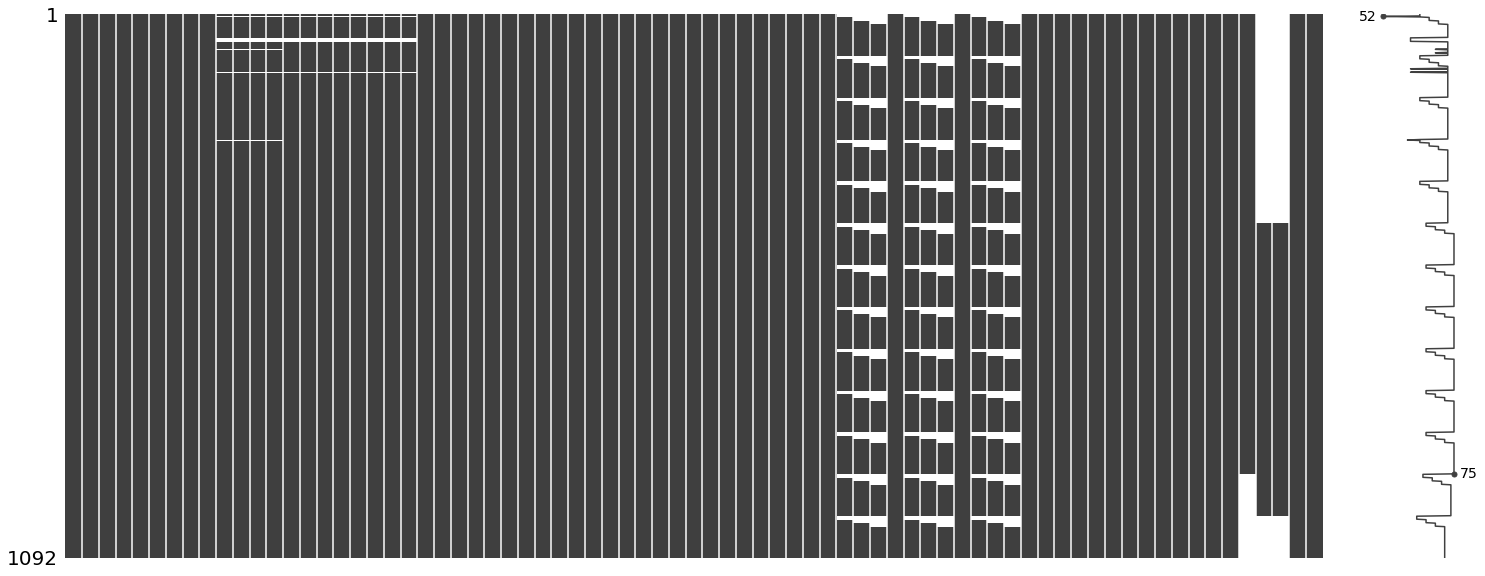

In [104]:
missingno.matrix(dataset_final)

In [105]:
dataset_final.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_NUTS3_2010_2022.csv", encoding = enc, index = False)